## <code>NTLM IR Experiment</code>

### Log-Likelihood for Document Ranking and Neural Translation Model for Query Likelihood

1. **Log-Likelihood for Document Ranking**:
   - Estimates the probability of generating the query $( q )$ given a document $( d )$.
   
     
      $$log p(q|d) = \sum_{i:c(q_i;d)>0} \log \left( \frac{p(q_i|d)}{\alpha_d * p(q_i|C)} \right) + n \log \alpha_d \text{........................Eq(1) }$$
      
   **Where:**
   - $p(q_i|d)$ is the probability of term \( q_i \) given document \( d \).
   - $alpha_d$ is a normalizing factor.
   - $p(q_i|C)$ is the probability of term \( q_i \) in the collection \( C \).
2. **Cosine Similarity**
    - $$ {cosine\_similarity}(u, w) = \frac{u \cdot w}{|u| |w|} $$
 
     $$p_t(w|u) = \frac{ \text{cos}(u', w)}{\sum_{u_0 \in V} \text{cos}(u, w)}   \text{............................................................................Eq(2) insert it into Eq(3) }$$  


3. **Translation Model for Query Likelihood**:
   - Models the process of query generation as a translation from document terms to query terms.
   
     
     $$p_t(w|d) = \sum_{u \in d} p_t(w|u) p(u|d)  \text{............................................................Eq(3) }$$ 
     
   **Where:**
   - $p_t(w|u)$ is the probability of translating document term $( u )$ into query term $( w )$.
   - $p(u|d)$ is the probability of term $( u )$ occurring in document $( d )$.

4. **The probability of term $u$ occurring in document $d$**
   - $$p(u|d) = \frac{{\text{tf}(u, d)}}{{\sum_{v \in d} \text{tf}(v, d)}} \text{............................................................Eq(4) }$$

   **Where:**
   - $p(u|d)$ represents the probability of term $( u )$ occurring in document $( d )$.
   - $\text{tf}(u, d)$ denotes the frequency of term $( u )$ in document $( d )$.
   - $\sum_{v \in d} \text{tf}(v, d)$ calculates the total number of terms in document $( d )$.
   
   
   
5. **Probability of Query Term $( q_i )$ in the Collection $( C )$ ---> $p(q_i|C)$**

   The probability  $p(q_i|C)$ represents the likelihood of term $(q_i)$ appearing in the entire collection of documents $(C)$. 
   It is calculated as the term frequency of $(q_i)$ in the collection $(C)$ divided by the total number of terms in the collection.

   - $$p(q_i|C) = \frac{\text{cf}(q_i, C)}{\sum_{v \in C} \text{cf}(v, C)} \text{............................................................Eq(5) }$$

   **Where:**
   - $\text{cf}(q_i, C)$ : Collection frequency of term $( q_i )$ in the collection $( C )$.
   - $\sum_{v \in C} \text{cf}(v, C)$: Total number of terms in the entire collection ( C )$.




6. **Connecting the Two Concepts**:
   
   - Specifically, $ p(q_i|d) $ can be estimated using $ p_t(w|d) $:
   
     $p_t(w|d) \approx p_t(q_i|d)$
     
     $p(u|d)$
     
     $p(q_i|C)$
     
   - Substitute these equations in $Eq (1)$

7. **Final Log-Likelihood for Document Ranking Equation Eq(1)**:
   - Using the Neural translation model, the log-likelihood equation becomes:
     
     $$log p(q|d) = \sum_{i:c(q_i;d)>0} \log \left( \frac{\sum_{u \in d} p_t(q_i|u) p(u|d)}{\alpha_d * p(q_i|C)} \right) + n \log \alpha_d$$
     
   

In [64]:
import gensim
import scipy
from gensim.models import Word2Vec
import numpy as np
import pyterrier as pt
import os
from collections import defaultdict
import pandas as pd
#from collections import MutableMapping
from tqdm import tqdm


In [65]:
# Set JAVA_HOME environment variable
java_home = r"C:\Program Files\Java\jdk-11"   # adjust your java JDK folder or use relative path in below
os.environ["JAVA_HOME"] = java_home

# Verify that JAVA_HOME is set correctly
print("JAVA_HOME set to:", os.environ.get("JAVA_HOME"))

if not pt.started():
  pt.init()

JAVA_HOME set to: C:\Program Files\Java\jdk-11


PyTerrier 0.10.0 has loaded Terrier 5.10 (built by craigm on 2024-08-22 17:33) and terrier-helper 0.0.8



In [9]:
import torch
from transformers import BertModel, BertTokenizer
import numpy as np
from collections import defaultdict
import pandas as pd
from tqdm import tqdm
import pyterrier as pt
import random

class BertEmbeddingManager:
    def __init__(self, model_name='castorini/monobert-large-msmarco'):
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.model = BertModel.from_pretrained(model_name)
        
        # Extract the input embeddings (token embeddings)
        self.word_embeddings = self.model.embeddings.word_embeddings
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.numpy()
            
        # Create a dictionary mapping tokens to their embeddings
        self.embedding_dict = {
            token: self.embedding_matrix[idx].astype(np.float32)
            for token, idx in self.vocab.items()
            if not token.startswith('[') and not token.startswith('##')  # Filter special tokens
        }

    def get_embedding(self, token):
        """Get embedding for a single token"""
        if token in self.embedding_dict:
            return self.embedding_dict[token]
        return None
    
    def __getitem__(self, token):
        """Allow dictionary-like access to embeddings"""
        return self.get_embedding(token)
    
    def __contains__(self, token):
        """Check if token exists in embedding dictionary"""
        return token in self.embedding_dict


In [10]:
import pyterrier as pt
import os

def initialize_pyterrier():
    """Initializes PyTerrier."""
    if not pt.started():
        pt.init()

def load_index(index_path):
    """
    Loads an existing index if it exists at the specified path.
    
    Parameters:
    - index_path: str, the path where the index is stored.
    
    Returns:
    - index: PyTerrier Index object
    """
    # Initialize PyTerrier
    initialize_pyterrier()

    # Set the path to the index properties
    index_properties_path = os.path.join(index_path, "data.properties")
    
    # Check if index exists
    if os.path.exists(index_properties_path):
        # Load the existing index
        indexref = pt.IndexRef.of(index_properties_path)
        print("Index already exists. Loading existing index...")
        # Load and return the index
        index = pt.IndexFactory.of(indexref)
        return index
    else:
        raise FileNotFoundError(f"No index found at {index_properties_path}. Please index the dataset first.")

def get_collection_statistics(index):
    """Prints and returns collection statistics."""
    stats = index.getCollectionStatistics()
    print(stats.toString())
    return stats


In [14]:
# Cell 1: Import Libraries and Initialize PyTerrier
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import pyterrier as pt
from collections import defaultdict



# Cell 2: Embedding Manager Class for Tokenization and Embeddings
from transformers import AutoTokenizer, AutoModel

class BertEmbeddingManager:
    def __init__(self, model_name):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
    
    def get_tokenizer(self):
        return self.tokenizer
    
    def get_embeddings(self, tokens):
        inputs = self.tokenizer(tokens, return_tensors="pt", padding=True, truncation=True)
        outputs = self.model(**inputs)
        return outputs.last_hidden_state.mean(dim=1).squeeze().detach().numpy()


# Cell 3: Term Frequency Calculations and Collection Frequency
def tokenize(text, tokenizer):
    return tokenizer.tokenize(text)

def calculate_term_frequencies(doc_texts, tokenizer):
    term_frequencies = {}
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = tokenize(text, tokenizer)
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies

def get_term_collection_freq(term, index):
    lexicon = index.getLexicon()
    lexicon_entry = lexicon.getLexiconEntry(term)
    return lexicon_entry.getFrequency() if lexicon_entry else 0


# Cell 4: Scoring Functions
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0

def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq.get(term, 0) / total_terms_in_doc

def p_u_given_C(term, get_term_collection_freq, total_terms_in_collection):
    return get_term_collection_freq(term) / total_terms_in_collection

def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, get_term_collection_freq, total_terms_in_collection, alpha):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  

        translation_prob_sum = 0.0
        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, get_term_collection_freq, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n)
            score += log_likelihood_ratio

    return score


# Cell 5: NTLM-based Document Retrieval and Ranking
def retrieve_and_rank_documents(topics, embeddings, index, total_terms_in_collection, alpha):
    results = []
    

    text_loader = pt.text.get_text(index, metadata=['text'])

    # Set up initial retrieval with DirichletLM
    dirichlet_pipeline = pt.BatchRetrieve(index, controls={"dirichletlm.mu": 1000}  >> text_loader)
    dirichlet_results = dirichlet_pipeline.transform(topics)
    doc_texts = {row['docno']: row['text'] for _, row in dirichlet_results.iterrows()}
    
    # Calculate term frequencies
    term_frequencies = calculate_term_frequencies(doc_texts, embeddings.tokenizer)

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics"):
        topic_id = row['qid']
        query_tokens = tokenize(row['query'], embeddings.tokenizer)
        scores = []
        
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        for doc_id, _ in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_tokens = tokenize(doc_text, embeddings.tokenizer)
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            
            ntlm_score = score_document(
                query_tokens, 
                doc_tokens, 
                embeddings, 
                doc_term_freq, 
                total_terms_in_doc, 
                lambda term: get_term_collection_freq(term, index), 
                total_terms_in_collection, 
                alpha
            )
            scores.append((doc_id, ntlm_score))
        
        ranked_scores = sorted(scores, key=lambda x: x[1], reverse=True)
        
        for rank, (doc_id, score) in enumerate(ranked_scores, 1):
            results.append((topic_id, doc_id, rank, score))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score'])




def main():
    # Initialize the model
    embeddings = BertEmbeddingManager("castorini/monobert-large-msmarco")
    
    if not pt.started():
        pt.init()

    # Load index
    base_dir = os.path.dirname(os.path.abspath("__file__"))  
    #index_path = os.path.join(base_dir, "index", "nfCorpus_index")
    index_path = os.path.join(base_dir, "index", "DOTGOV_index")

    index = load_index(index_path)
    get_collection_statistics(index)

    # Collection statistics
    collection_stats = index.getCollectionStatistics()
    total_terms_in_collection = collection_stats.getNumberOfTokens()
  

      # Load topics and qrels
    def load_topics_and_qrels(topics_path, qrels_path):
        topics = pd.read_csv(topics_path, sep=',')
        qrels = pd.read_csv(qrels_path, sep=',')
        topics['qid'] = topics['qid'].astype(str)
        qrels['qid'] = qrels['qid'].astype(str)
        qrels['docno'] = qrels['docno'].astype(str)
        return topics, qrels

    # Evaluation
    def evaluate_results(topics, qrels, reranked_results_df, dirichlet_pipeline):
        return pt.Experiment(
            [reranked_results_df, dirichlet_pipeline],
            topics, 
            qrels, 
            eval_metrics=["map", "P_10", "ndcg"], 
            names=["NTLM", "Dirichlet"], 
            filter_by_qrels=True, 
            filter_by_topics=True
        )
    

    # Load topics and qrels
    topics_path = os.path.join("topics", "DOTGOV_query.csv")
    qrels_path = os.path.join("qrels", "DOTGOV_qrels.csv")
    topics, qrels = load_topics_and_qrels(topics_path, qrels_path)
    # Load topics and qrels
    #topics = pd.read_csv(topics_path)


    # Reranked NTLM results
    reranked_results_df = retrieve_and_rank_documents(
        topics,
        embeddings,
        index,
        total_terms_in_collection,
        alpha=0.9,
    )

    # Evaluate results
    evaluation_results = evaluate_results(topics, qrels, reranked_results_df)
    print(evaluation_results)

if __name__ == "__main__":
    main()


Index already exists. Loading existing index...
17:38:02.644 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading data file directly from disk (SLOW) - try index.meta.data-source=fileinmem in the index properties file. 875.9 MiB of memory would be required.
Number of documents: 1247753
Number of terms: 2899192
Number of postings: 277718803
Number of fields: 0
Number of tokens: 902632129
Field names: []
Positions:   false



TypeError: ValueError() takes no keyword arguments

In [16]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import pyterrier as pt
from collections import defaultdict
from transformers import AutoTokenizer, AutoModel


def tokenize(text, tokenizer):
    return tokenizer.tokenize(text)

def calculate_term_frequencies(doc_texts, tokenizer):
    term_frequencies = {}
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = tokenize(text, tokenizer)
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies

def get_term_collection_freq(term, index):
    lexicon = index.getLexicon()
    lexicon_entry = lexicon.getLexiconEntry(term)
    return lexicon_entry.getFrequency() if lexicon_entry else 0

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0

def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq.get(term, 0) / total_terms_in_doc

def p_u_given_C(term, get_term_collection_freq, total_terms_in_collection):
    return get_term_collection_freq(term) / total_terms_in_collection

def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, get_term_collection_freq, total_terms_in_collection, alpha):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  

        translation_prob_sum = 0.0
        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, get_term_collection_freq, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n)
            score += log_likelihood_ratio

    return score

def retrieve_and_rank_documents(topics, embeddings, index, total_terms_in_collection, alpha):
    results = []
    
    # Create a text loader transformer
    text_loader = pt.text.get_text(index, metadata=['text'])
    
    # Create Dirichlet pipeline
    dirichlet_pipeline = pt.BatchRetrieve(index, controls={"dirichletlm.mu": 1000}) >> text_loader
    
    # Transform topics to get initial retrieval
    dirichlet_results = dirichlet_pipeline.transform(topics)
    
    # Extract doc texts
    doc_texts = {row['docno']: row['text'] for _, row in dirichlet_results.iterrows()}
    
    # Calculate term frequencies
    term_frequencies = calculate_term_frequencies(doc_texts, embeddings.get_tokenizer())

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics"):
        topic_id = row['qid']
        query_tokens = tokenize(row['query'], embeddings.get_tokenizer())
        scores = []
        
        # Filter retrieved docs for current topic
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        
        for doc_id, _ in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_tokens = tokenize(doc_text, embeddings.get_tokenizer())
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            
            ntlm_score = score_document(
                query_tokens, 
                doc_tokens, 
                embeddings, 
                doc_term_freq, 
                total_terms_in_doc, 
                lambda term: get_term_collection_freq(term, index), 
                total_terms_in_collection, 
                alpha
            )
            scores.append((doc_id, ntlm_score))
        
        ranked_scores = sorted(scores, key=lambda x: x[1], reverse=True)
        
        for rank, (doc_id, score) in enumerate(ranked_scores, 1):
            results.append((topic_id, doc_id, rank, score))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score'])

def load_index(index_path):
    return pt.IndexFactory.of(index_path)

def get_collection_statistics(index):
    collection_stats = index.getCollectionStatistics()
    print(f"Total Documents: {collection_stats.getNumberOfDocuments()}")
    print(f"Total Tokens: {collection_stats.getNumberOfTokens()}")
    print(f"Unique Terms: {collection_stats.getNumberOfUniqueTerms()}")

def load_topics_and_qrels(topics_path, qrels_path):
    topics = pd.read_csv(topics_path, sep=',')
    qrels = pd.read_csv(qrels_path, sep=',')
    topics['qid'] = topics['qid'].astype(str)
    qrels['qid'] = qrels['qid'].astype(str)
    qrels['docno'] = qrels['docno'].astype(str)
    return topics, qrels

def evaluate_results(topics, qrels, reranked_results_df, dirichlet_pipeline):
    return pt.Experiment(
        [reranked_results_df, dirichlet_pipeline],
        topics, 
        qrels, 
        eval_metrics=["map", "P_10", "ndcg"], 
        names=["NTLM", "Dirichlet"], 
        filter_by_qrels=True, 
        filter_by_topics=True
    )

def main():
    # Initialize the model
    embeddings = BertEmbeddingManager("castorini/monobert-large-msmarco")
    
    if not pt.started():
        pt.init()

    base_dir = os.path.dirname(os.path.abspath("__file__"))  
    #index_path = os.path.join(base_dir, "index", "nfCorpus_index")
    index_path = os.path.join(base_dir, "index", "DOTGOV_index")


    index = load_index(index_path)
    get_collection_statistics(index)

    # Collection statistics
    collection_stats = index.getCollectionStatistics()
    total_terms_in_collection = collection_stats.getNumberOfTokens()

    # Load topics and qrels
    topics_path = os.path.join("topics", "DOTGOV_query.csv")
    qrels_path = os.path.join("qrels", "DOTGOV_qrels.csv")
    topics, qrels = load_topics_and_qrels(topics_path, qrels_path)

    # Create Dirichlet pipeline for comparison
    dirichlet_pipeline = pt.BatchRetrieve(index, controls={"dirichletlm.mu": 1000})

    # Reranked NTLM results
    reranked_results_df = retrieve_and_rank_documents(
        topics,
        embeddings,
        index,
        total_terms_in_collection,
        alpha=0.9,
    )

    # Evaluate results
    evaluation_results = evaluate_results(topics, qrels, reranked_results_df, dirichlet_pipeline)
    print(evaluation_results)

if __name__ == "__main__":
    main()

17:52:19.933 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading data file directly from disk (SLOW) - try index.meta.data-source=fileinmem in the index properties file. 875.9 MiB of memory would be required.
Total Documents: 1247753
Total Tokens: 902632129
Unique Terms: 2899192


Token indices sequence length is longer than the specified maximum sequence length for this model (588 > 512). Running this sequence through the model will result in indexing errors
Processing Topics:   0%|          | 0/50 [00:00<?, ?it/s]


TypeError: argument of type 'BertEmbeddingManager' is not iterable

In [8]:
# All-in-one code for Jupyter Notebook

import os
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
import numpy as np
import pyterrier as pt

# Initialize PyTerrier
if not pt.started():
    pt.init()

# Tokenization
def tokenize(text, tokenizer):
    return tokenizer.tokenize(text)

# Term Frequency Calculations
def calculate_term_frequencies(doc_texts, tokenizer):
    term_frequencies = {}
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = tokenize(text, tokenizer)
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies

def get_term_collection_freq(term, index):
    lexicon = index.getLexicon()
    lexicon_entry = lexicon.getLexiconEntry(term)
    return lexicon_entry.getFrequency() if lexicon_entry else 0

def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    term_frequency = doc_term_freq.get(term, 0)
    return term_frequency / total_terms_in_doc if total_terms_in_doc > 0 else 0

def p_u_given_C(term, get_term_collection_freq, total_terms_in_collection):
    term_collection_frequency = get_term_collection_freq(term)
    return term_collection_frequency / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Cosine Similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0

def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, get_term_collection_freq, total_terms_in_collection, alpha):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  

        translation_prob_sum = 0.0
        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, get_term_collection_freq, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n)
            score += log_likelihood_ratio

    return score

# Retrieval Pipeline
def create_dirichlet_pipeline(index, mu=1500, num_results=100, metadata=['text']): 
    text_loader = pt.text.get_text(index, metadata=metadata)
    dirichlet_pipeline = (
        pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'mu': mu}, 
                        num_results=num_results, verbose=True) 
        >> text_loader
    )
    return dirichlet_pipeline

def retrieve_and_rank_documents(topics, embeddings, index, total_terms_in_collection, alpha, dirichlet_weight, ntlm_weight):
    results = []
    dirichlet_pipeline = create_dirichlet_pipeline(index)
    dirichlet_results = dirichlet_pipeline.transform(topics)
    doc_texts = {row['docno']: row['text'] for _, row in dirichlet_results.iterrows()}
    
    # Calculate term frequencies
    term_frequencies = calculate_term_frequencies(doc_texts, embeddings.tokenizer)

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics"):
        topic_id = row['qid']
        query_tokens = tokenize(row['query'], embeddings.tokenizer)
        scores = []
        
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_tokens = tokenize(doc_text, embeddings.tokenizer)
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            
            ntlm_score = score_document(
                query_tokens, 
                doc_tokens, 
                embeddings, 
                doc_term_freq, 
                total_terms_in_doc, 
                lambda term: get_term_collection_freq(term, index), 
                total_terms_in_collection, 
                alpha
            )
            scores.append((doc_id, ntlm_score, dirichlet_score))
        
        combined_scores = [
            (doc_id, ntlm_weight * ntlm_score + dirichlet_weight * dirichlet_score)
            for doc_id, ntlm_score, dirichlet_score in scores
        ]
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        for rank, (doc_id, score) in enumerate(ranked_scores, 1):
            results.append((topic_id, doc_id, rank, score))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score'])

# Load topics and qrels
def load_topics_and_qrels(topics_path, qrels_path):
    topics = pd.read_csv(topics_path, sep=',')
    qrels = pd.read_csv(qrels_path, sep=',')
    topics['qid'] = topics['qid'].astype(str)
    qrels['qid'] = qrels['qid'].astype(str)
    qrels['docno'] = qrels['docno'].astype(str)
    return topics, qrels

# Evaluation
def evaluate_results(topics, qrels, reranked_results_df, dirichlet_pipeline):
    return pt.Experiment(
        [reranked_results_df, dirichlet_pipeline],
        topics, 
        qrels, 
        eval_metrics=["map", "P_10", "ndcg"], 
        names=["NTLM", "Dirichlet"], 
        filter_by_qrels=True, 
        filter_by_topics=True
    )

# Main Script
def main():
    # Initialize embeddings (Example Manager Initialization)
    embeddings = BertEmbeddingManager("castorini/monobert-large-msmarco")  # Adjust with your embedding manager

    # Load index
    base_dir = os.path.dirname(os.path.abspath("__file__"))  
    #index_path = os.path.join(base_dir, "index", "nfCorpus_index")
    index_path = os.path.join(base_dir, "index", "DOTGOV_index")

    index = load_index(index_path)
    get_collection_statistics(index)

    # Collection statistics
    collection_stats = index.getCollectionStatistics()
    total_terms_in_collection = collection_stats.getNumberOfTokens()
  
    # Load topics and qrels
    topics_path = os.path.join("topics", "DOTGOV_query.csv")
    qrels_path = os.path.join("qrels", "DOTGOV_qrels.csv")
    topics, qrels = load_topics_and_qrels(topics_path, qrels_path)

    # Dirichlet Pipeline
    dirichlet_pipeline = create_dirichlet_pipeline(index, mu=1500, num_results=100, metadata=['text'])
    
    # Reranked NTLM results
    reranked_results_df = retrieve_and_rank_documents(
        topics,
        embeddings,
        index,
        total_terms_in_collection,
        alpha=0.9,
        dirichlet_weight=0,
        ntlm_weight=1,
    )

    # Evaluate results
    evaluation_results = evaluate_results(topics, qrels, reranked_results_df, dirichlet_pipeline)
    print(evaluation_results)

# Run main
main()


Index already exists. Loading existing index...
16:09:46.464 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading data file directly from disk (SLOW) - try index.meta.data-source=fileinmem in the index properties file. 875.9 MiB of memory would be required.
Number of documents: 1247753
Number of terms: 2899192
Number of postings: 277718803
Number of fields: 0
Number of tokens: 902632129
Field names: []
Positions:   false



Processing Topics:   0%|          | 0/50 [00:00<?, ?it/s]C:\Users\dolla\AppData\Local\Temp\ipykernel_52060\2505896636.py:63: RuntimeWarning: divide by zero encountered in scalar divide
  return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))
Processing Topics:   2%|▏         | 1/50 [00:09<07:34,  9.28s/it]C:\Users\dolla\AppData\Local\Temp\ipykernel_52060\2505896636.py:63: RuntimeWarning: divide by zero encountered in scalar divide
  return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))
Processing Topics:   4%|▍         | 2/50 [00:30<12:59, 16.24s/it]C:\Users\dolla\AppData\Local\Temp\ipykernel_52060\2505896636.py:63: RuntimeWarning: divide by zero encountered in scalar divide
  return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))
Processing Topics:   6%|▌         | 3/50 [00:55<15:44, 20.09s/it]C:\Users\dolla\AppData\Local\Temp\ipykernel_52060\2505896636.py:63: RuntimeWarning: divide by zero encountered in scalar divide
  return (n

        name       map   P_10      ndcg
0       NTLM  0.083745  0.168  0.224445
1  Dirichlet  0.118951  0.192  0.262832


In [38]:
import pyterrier as pt
import os
from pyterrier.datasets import get_dataset

# Initialize PyTerrier
if not pt.started():
    pt.init()

# Set index path (modify this to your desired location)
index_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\NTLM_Experiment\var\nfCorpus_index"
index_properties_path = os.path.join(index_path, "data.properties")

# Check if the index exists
if os.path.exists(index_properties_path):
    # If the index exists, load the index reference
    indexref = pt.IndexRef.of(index_properties_path)
    #print("Index already exists. Loading existing index...")
else:
    # If index doesn't exist, create a new index
    #print("Index does not exist. Indexing the BEIR Quora dataset...")
    
    # Get the BEIR Quora dataset
    dataset = get_dataset("irds:beir/nfcorpus/dev") 
    
    # Create the indexer
    indexer = pt.IterDictIndexer(index_path, 
                                 meta={'docno': 20, 'text': 4096},
                                 overwrite=True)
    
    # Index the dataset
    indexref = indexer.index(dataset.get_corpus_iter(), fields=['text'])

# Get the index reference and print statistics
index = pt.IndexFactory.of(indexref)
print(index.getCollectionStatistics().toString())

Number of documents: 3633
Number of terms: 18315
Number of postings: 331393
Number of fields: 1
Number of tokens: 534114
Field names: [text]
Positions:   false



In [77]:


# Define the relative paths based on the notebook's location
DISK45_PATH = os.path.join("..","..", "Data", "WSJ_Doc", "wsj", "concatenated_WSJ")
INDEX_DIR = r"C:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\NTLM_Experiment\var\WSJ_index_text"


# Check if the index exists
if os.path.exists(os.path.join(INDEX_DIR, "data.properties")):
    indexref = pt.IndexRef.of(os.path.join(INDEX_DIR, "data.properties"))
else:
    # Find files in the directory
    files = pt.io.find_files(DISK45_PATH)
    
    # Remove unwanted files
    bad = ['/CR/', '/AUX/', 'READCHG', 'READMEFB', 'READFRCG', 'READMEFR', 'READMEFT', 'READMELA']
    for b in bad:
        files = list(filter(lambda f: b not in f, files))
    
    # Check if files list is empty and raise an error if it is
    if not files:
        raise ValueError(f"No files found in the directory {DISK45_PATH}")
    
    # Index the remaining files
    indexer = pt.TRECCollectionIndexer(
        INDEX_DIR,
        # Record that we save additional document metadata called 'text'
        meta={'docno': 26, 'text': 2048},
        # The tags from which to save the text. ELSE is special tag name, which means anything not consumed by other tags.
        meta_tags={'text': 'ELSE'},
        verbose=True
    )
    indexref = indexer.index(files)

# Create an index object
index = pt.IndexFactory.of(indexref)

# Print collection statistics
print(index.getCollectionStatistics().toString())


Number of documents: 173252
Number of terms: 176210
Number of postings: 29484536
Number of fields: 0
Number of tokens: 49044405
Field names: []
Positions:   false



## Loading the AP Topics & qrels

In [78]:
# Define the relative paths based on the notebook's location

#topics_path = os.path.join("..", "Data", "WSJ_Doc", "wsj", "topics", "all_topics_fixed.txt")
#qrels_path = os.path.join("..", "Data", "WSJ_Doc", "wsj", "qrels", "WSJ_only.txt")
#index_path = os.path.join("..", "Data", "WSJ_Doc", "wsj", "index_WSJ")

# Load topics and qrels from text files

#topics_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\AP_query.csv"
#qrels_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\qrels\AP_qrels.csv"


#topics = pt.io.read_topics(topics_path)
#qrels = pt.io.read_qrels(qrels_path)
#topics= pd.read_csv(topics_path, sep=',', header=0) 
#qrels = pd.read_csv(qrels_path, sep=',', header=0) 


import pandas as pd
topics_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\WSJ_queries.csv"
qrels_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\qrels\WSJ_qrels.csv"

topics_df = pd.read_csv(topics_path, sep=',', header=0) 
topics = topics_df[:]
qrels = pd.read_csv(qrels_path, sep=',', header=0) 

In [68]:
qrels

,qid,docno,label
0,51,AP880301-0271,1
1,51,AP880302-0275,1
2,51,AP880311-0301,1
3,51,AP880316-0292,1
4,51,AP880318-0287,1
...,...,...,...
63203,200,AP891129-0238,0
63204,200,AP891130-0262,0
63205,200,AP891204-0017,0
63206,200,AP891214-0236,0


In [69]:
topics

,qid,query
0,51,airbus subsidies
1,52,south african sanctions
2,53,leveraged buyouts
3,54,satellite launch contracts
4,55,insider trading
...,...,...
145,196,school choice voucher system and its effects u...
146,197,reform of the jurisprudence system to stop jur...
147,198,gene therapy and its benefits to humankind
148,199,legality of medically assisted suicides


### Dirichlet fine tuning

12:19:38.705 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading data file directly from disk (SLOW) - try index.meta.data-source=fileinmem in the index properties file. 2.8 GiB of memory would be required.


BR(DirichletLM): 100%|██████████| 45/45 [00:11<00:00,  3.98q/s]


Dataset: MS MARCO, mu: 0, MAP: 0.003387949710903657


BR(DirichletLM): 100%|██████████| 45/45 [00:10<00:00,  4.24q/s]


Dataset: MS MARCO, mu: 300, MAP: 0.3532091505147759


...

Dataset: FiQA, mu: 1500, MAP: 0.0


BR(DirichletLM): 100%|██████████| 16/16 [00:01<00:00, 12.90q/s]


Dataset: FiQA, mu: 1800, MAP: 0.0


BR(DirichletLM): 100%|██████████| 16/16 [00:01<00:00, 14.75q/s]


Dataset: FiQA, mu: 2100, MAP: 0.0


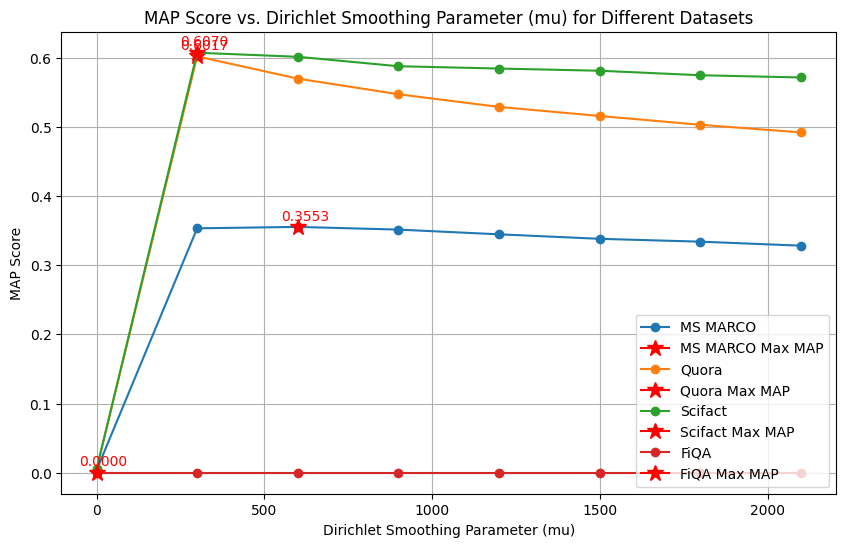

In [102]:
import pyterrier as pt
import pandas as pd
import matplotlib.pyplot as plt

# Initialize PyTerrier if not already initialized
if not pt.started():
    pt.init()

# Define dataset paths including index paths
datasets = {

    "MS MARCO": {
    "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\msmarco-document-trec-dl-2020_index",
    "topics_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\topics\msmarco_trec_dl_2020_query.csv",
    "qrels_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\qrels\msmarco_trec_dl_2020_qrels.csv"
    },
    
    "Quora": {
        "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\quora_index",
        "topics_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\topics\beir_quora_query.csv",
        "qrels_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\qrels\beir_quora_qrels.csv"

    },
    "Scifact": {
        "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\scifact_index",
        "topics_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\topics\beir_scifact_test_query.csv",
        "qrels_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\qrels\beir_scifact_test_qrels.csv"

    },

    "FiQA": {
    "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\fiqa_index",
    "topics_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\topics\beir_fiqa_dev_query.csv",
    "qrels_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\qrels\beir_fever_dev_qrels.csv"
    
}
}


# Define the range of mu values to test
mu_values = list(range(0, 2101, 300))
results = {dataset: [] for dataset in datasets.keys()}

# Calculate MAP scores for each dataset and each mu value
for dataset_name, paths in datasets.items():
    # Load the index for the current dataset
    index = pt.IndexFactory.of(paths['index_path'])
    text_loader = pt.text.get_text(index, metadata=['text'])
    
    # Load topics and qrels for the current dataset
    topics = pd.read_csv(paths['topics_path'], sep=',', header=0)
    qrels = pd.read_csv(paths['qrels_path'], sep=',', header=0)

    # Convert 'qid' and 'docno' columns to strings for consistency
    topics['qid'] = topics['qid'].astype(str)
    qrels['qid'] = qrels['qid'].astype(str)
    qrels['docno'] = qrels['docno'].astype(str)

    for mu in mu_values:
        # Create the retrieval pipeline for the current mu value
        dirichlet_pipeline = pt.BatchRetrieve(
            index, wmodel="DirichletLM", controls={'dirichletlm.mu': mu}, num_results=100, verbose=True
        ) >> text_loader

        # Run the experiment to calculate MAP
        experiment_result = pt.Experiment(
            [dirichlet_pipeline],
            topics,
            qrels,
            eval_metrics=["map"],
            names=[f"{dataset_name}_mu_{mu}"],
            filter_by_qrels=True,
            filter_by_topics=True
        )

        # Store the MAP score for the current mu and dataset
        results[dataset_name].append(experiment_result['map'][0])
        print(f"Dataset: {dataset_name}, mu: {mu}, MAP: {experiment_result['map'][0]}")

# Plot mu vs. MAP for each dataset and mark the highest point
plt.figure(figsize=(10, 6))
for dataset_name, map_scores in results.items():
    # Plot MAP scores for the current dataset
    plt.plot(mu_values, map_scores, marker='o', linestyle='-', label=dataset_name)
    
    # Find the maximum MAP value and corresponding mu
    max_map = max(map_scores)
    max_mu = mu_values[map_scores.index(max_map)]
    
    # Highlight the maximum MAP point with a star marker and annotate it
    plt.plot(max_mu, max_map, marker='*', markersize=12, color='red', label=f'{dataset_name} Max MAP')
    plt.annotate(f"{max_map:.4f}", (max_mu, max_map), textcoords="offset points", xytext=(5,5), ha='center', color='red')

plt.xlabel("Dirichlet Smoothing Parameter (mu)")
plt.ylabel("MAP Score")
plt.title("MAP Score vs. Dirichlet Smoothing Parameter (mu) for Different Datasets")
plt.legend()
plt.grid(True)
plt.show()


BR(DirichletLM): 100%|██████████| 150/150 [00:04<00:00, 34.51q/s]


Dataset: AP, mu: 0, MAP: 0.0063391910978676585


BR(DirichletLM): 100%|██████████| 150/150 [00:03<00:00, 40.73q/s]


Dataset: AP, mu: 300, MAP: 0.1205279969114945


BR(DirichletLM): 100%|██████████| 150/150 [00:03<00:00, 40.38q/s]


...

Dataset: NQ, mu: 1500, MAP: 0.1667112880201885


BR(DirichletLM): 100%|██████████| 3452/3452 [09:42<00:00,  5.92q/s]


Dataset: NQ, mu: 1800, MAP: 0.1634874454854137


BR(DirichletLM): 100%|██████████| 3452/3452 [09:46<00:00,  5.89q/s] 


Dataset: NQ, mu: 2100, MAP: 0.15932059468180923


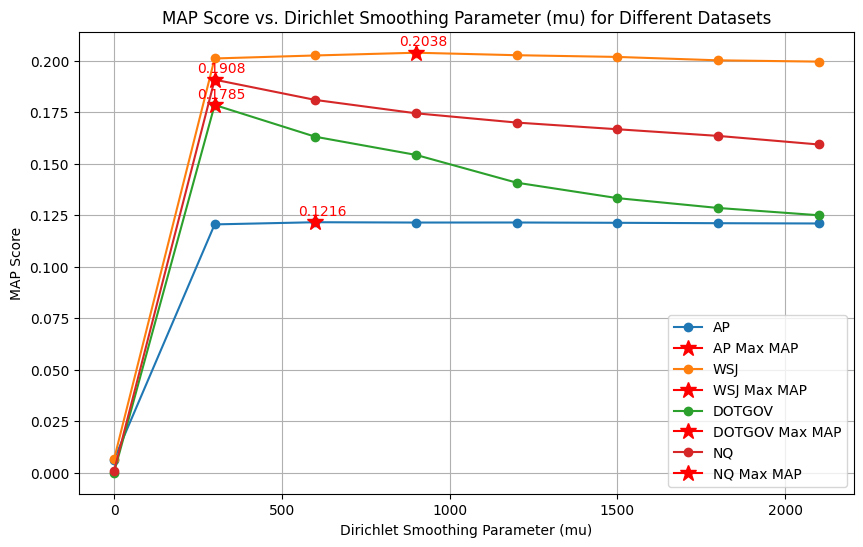

In [ ]:
import pyterrier as pt
import pandas as pd
import matplotlib.pyplot as plt

# Initialize PyTerrier if not already initialized
if not pt.started():
    pt.init()

# Define dataset paths including index paths
datasets = {
    "Quora": {
        "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\quora_index",
        "topics_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\topics\beir_quora_query.csv",
        "qrels_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\qrels\beir_quora_qrels.csv"

    },
    "Scifact": {
        "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\scifact_index",
        "topics_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\topics\beir_scifact_test_query.csv",
        "qrels_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\qrels\beir_scifact_test_qrels.csv"

    },
    "MS MARCO": {
        "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\msmarco-document-trec-dl-2020_index",
        "topics_path": r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\msmarco_trec_dl_2020_query.csv",
        "qrels_path": r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\qrels\msmarco_trec_dl_2020_qrels.csv"
    },
    "FiQA": {
    "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\fiqa_index",
    "topics_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\topics\beir_fiqa_dev_query.csv",
    "qrels_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\qrels\beir_fever_dev_qrels.csv"
    
}
}


# Define the range of mu values to test
mu_values = list(range(0, 2101, 300))
results = {dataset: [] for dataset in datasets.keys()}

# Calculate MAP scores for each dataset and each mu value
for dataset_name, paths in datasets.items():
    # Load the index for the current dataset
    index = pt.IndexFactory.of(paths['index_path'])
    text_loader = pt.text.get_text(index, metadata=['text'])
    
    # Load topics and qrels for the current dataset
    topics = pd.read_csv(paths['topics_path'], sep=',', header=0)
    qrels = pd.read_csv(paths['qrels_path'], sep=',', header=0)

    # Convert 'qid' and 'docno' columns to strings for consistency
    topics['qid'] = topics['qid'].astype(str)
    qrels['qid'] = qrels['qid'].astype(str)
    qrels['docno'] = qrels['docno'].astype(str)

    for mu in mu_values:
        # Create the retrieval pipeline for the current mu value
        dirichlet_pipeline = pt.BatchRetrieve(
            index, wmodel="DirichletLM", controls={'dirichletlm.mu': mu}, num_results=100, verbose=True
        ) >> text_loader

        # Run the experiment to calculate MAP
        experiment_result = pt.Experiment(
            [dirichlet_pipeline],
            topics,
            qrels,
            eval_metrics=["map"],
            names=[f"{dataset_name}_mu_{mu}"],
            filter_by_qrels=True,
            filter_by_topics=True
        )

        # Store the MAP score for the current mu and dataset
        results[dataset_name].append(experiment_result['map'][0])
        print(f"Dataset: {dataset_name}, mu: {mu}, MAP: {experiment_result['map'][0]}")

# Plot mu vs. MAP for each dataset and mark the highest point
plt.figure(figsize=(10, 6))
for dataset_name, map_scores in results.items():
    # Plot MAP scores for the current dataset
    plt.plot(mu_values, map_scores, marker='o', linestyle='-', label=dataset_name)
    
    # Find the maximum MAP value and corresponding mu
    max_map = max(map_scores)
    max_mu = mu_values[map_scores.index(max_map)]
    
    # Highlight the maximum MAP point with a star marker and annotate it
    plt.plot(max_mu, max_map, marker='*', markersize=12, color='red', label=f'{dataset_name} Max MAP')
    plt.annotate(f"{max_map:.4f}", (max_mu, max_map), textcoords="offset points", xytext=(5,5), ha='center', color='red')

plt.xlabel("Dirichlet Smoothing Parameter (mu)")
plt.ylabel("MAP Score")
plt.title("MAP Score vs. Dirichlet Smoothing Parameter (mu) for Different Datasets")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
},
    "Quora": {
    "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\quora_index",
    "topics_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\topics\beir_quora_query.csv",
    "qrels_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\qrels\beir_quora_qrels.csv"




datasets = {
    "AP": {
        "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\AP_index",
        "topics_path": r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\AP_query.csv",
        "qrels_path": r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\qrels\AP_qrels.csv"
    },
    "WSJ": {
        "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\WSJ_index",
        "topics_path": r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\WSJ_queries.csv",
        "qrels_path": r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\qrels\WSJ_qrels.csv"
    },
    "DOTGOV": {
        "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\DOTGOV_index",
        "topics_path": r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\DOTGOV_query.csv",
        "qrels_path": r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\qrels\DOTGOV_qrels.csv"
    },
    "NQ": {
    "index_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\index\nq_index",
    "topics_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\topics\beir_nq_query.csv",
    "qrels_path": r"C:\Eyasu\th\thesis_eyasu\NTLM_modules\qrels\beir_nq_qrels.csv"
    
}
}

In [11]:
# Load pre-trained word embeddings
#word_embeddings_path = os.path.join("../", "NTLM_Experiment", "GoogleNews-vectors-negative300-SLIM.bin")   # download the pretrained model

word_embeddings_path = r"C:\Users\dolla\NTLM\GoogleNews-vectors-negative300.bin"   
#word_embeddings_path = r"C:\Users\dolla\NTLM\GoogleNews-vectors-negative300-SLIM.bin"   
#word_embeddings_path = r"D:\Thesis_New\thesis_eyasu\Data\Word_Embedding\word_vectors.bin"
word_embeddings = gensim.models.KeyedVectors.load_word2vec_format(word_embeddings_path, binary=True)


In [63]:

import gensim
import numpy as np
from collections import defaultdict
from typing import Dict, List, Tuple
import math

class WordTranslator:
    def __init__(self, word_embeddings_path: str):
        """
        Initialize the word translator with pre-trained word embeddings
        """
        self.word_embeddings = gensim.models.KeyedVectors.load_word2vec_format(
            word_embeddings_path, binary=True
        )
        self.vocabulary = set(self.word_embeddings.index_to_key)
        
    def get_nearest_neighbors(self, word: str, k: int = 8) -> List[Tuple[str, float]]:
        """
        Find k nearest neighbors for a given word based on cosine similarity
        """
        if word not in self.vocabulary:
            return []
        
        similar_words = self.word_embeddings.most_similar(word, topn=k)
        return similar_words
    
    def calculate_translation_probability(self, source_word: str, target_word: str,
                                       temperature: float = 0.1) -> float:
        """
        Calculate translation probability pt(w|u) using NTLM approach
        Args:
            source_word: The source word u
            target_word: The target word w
            temperature: Temperature parameter for controlling probability distribution
        """
        if source_word not in self.vocabulary or target_word not in self.vocabulary:
            return 0.0
        
        # Calculate cosine similarity
        similarity = self.word_embeddings.similarity(source_word, target_word)
        
        # Convert similarity to probability using softmax-like normalization
        # Higher temperature leads to more uniform probabilities
        probability = math.exp(similarity / temperature)
        
        # Get normalization term (sum of exp(sim(u,w')/temperature) for all w' in vocabulary)
        # Note: For efficiency, we only consider top-k nearest neighbors
        nearest_neighbors = self.get_nearest_neighbors(source_word, k=8)
        normalization_term = sum(math.exp(sim / temperature) 
                               for _, sim in nearest_neighbors)
        
        return probability / normalization_term if normalization_term > 0 else 0.0
    
    def get_translation_candidates(self, source_word: str, 
                                 threshold: float = 0.01) -> List[Tuple[str, float]]:
        """
        Get all possible translation candidates with their probabilities
        Args:
            source_word: The source word to translate
            threshold: Minimum probability threshold for considering a translation
        """
        if source_word not in self.vocabulary:
            return []
        
        # Get nearest neighbors as potential translation candidates
        candidates = self.get_nearest_neighbors(source_word, k=8)
        
        # Calculate translation probabilities for each candidate
        translation_probs = []
        for candidate, _ in candidates:
            prob = self.calculate_translation_probability(source_word, candidate)
            if prob >= threshold:
                translation_probs.append((candidate, prob))
        
        # Sort by probability in descending order
        return sorted(translation_probs, key=lambda x: x[1], reverse=True)

# Example usage
def main():
    # Initialize translator with your embeddings
    #word_embeddings_path = r"C:\Users\dolla\NTLM\GoogleNews-vectors-negative300.bin"
    #word_embeddings_path = r"C:\Users\dolla\Downloads\old and gas CBOW word embedding\model.bin"  #word2vec_model
    #word_embeddings_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\Word_Embedding\custom_skipgram_model.bin"
    
    word_embeddings_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\Word_Embedding\word2vec_models\AP_skipgram_model.bin" 
    #word_embeddings_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\Word_Embedding\word2vec_models\AP_cbow_model.bin"
    #word_embeddings_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\Word_Embedding\word2vec_models\WSJ_skipgram_model.bin"
    #word_embeddings_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\Word_Embedding\word2vec_models\WSJ_cbow_model.bin" 


    translator = WordTranslator(word_embeddings_path)
    
    # Example translations
    source_word = "visitor" #geology
    translations = translator.get_translation_candidates(source_word)
    
    print(f"Translation candidates for '{source_word}':")
    for word, prob in translations:
        print(f"{word}: {prob:.4f}")

if __name__ == "__main__":
    main()

Translation candidates for 'visitor':
visitors: 0.4131
tourist: 0.1325
visits: 0.0909
tourists: 0.0879
visiting: 0.0752
visit: 0.0727
visited: 0.0642
resident: 0.0634


In [66]:
import torch
import numpy as np
from transformers import BertTokenizer, BertModel
from typing import List, Tuple
import math

class BertWordTranslator:
    def __init__(self, bert_model_name: str = 'bert-base-uncased'):
        """
        Initialize the word translator with BERT input embeddings
        """
        # Load BERT model and tokenizer
        self.tokenizer = BertTokenizer.from_pretrained(bert_model_name)
        self.model = BertModel.from_pretrained(bert_model_name)
        
        # Extract the input embeddings (token embeddings) from BERT
        self.word_embeddings = self.model.embeddings.word_embeddings
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.detach().cpu().numpy()
        
        # Store embedding dimension
        self.embedding_dim = self.embedding_matrix.shape[1]
        
    def get_word_embedding(self, word: str) -> np.ndarray:
        """
        Get the embedding vector for a given word.
        """
        token_id = self.vocab.get(word, None)
        if token_id is None:
            return None  # Word not found in BERT's vocabulary
        return self.embedding_matrix[token_id]
    
    def cosine_similarity(self, vec1: np.ndarray, vec2: np.ndarray) -> float:
        """
        Calculate cosine similarity between two vectors.
        """
        if vec1 is None or vec2 is None:
            return 0.0
        return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    
    def get_nearest_neighbors(self, word: str, k: int = 6) -> List[Tuple[str, float]]:
        """
        Find k nearest neighbors for a given word based on cosine similarity.
        """
        source_embedding = self.get_word_embedding(word)
        if source_embedding is None:
            return []
        
        similarities = []
        for idx, embedding in enumerate(self.embedding_matrix):
            target_word = self.reverse_vocab[idx]
            similarity = self.cosine_similarity(source_embedding, embedding)
            similarities.append((target_word, similarity))
        
        # Sort by similarity and return top-k
        return sorted(similarities, key=lambda x: x[1], reverse=True)[:k]
    
    def calculate_translation_probability(self, source_word: str, target_word: str,
                                          temperature: float = 0.01) -> float:
        """
        Calculate translation probability pt(w|u) using NTLM approach.
        """
        source_embedding = self.get_word_embedding(source_word)
        target_embedding = self.get_word_embedding(target_word)
        
        if source_embedding is None or target_embedding is None:
            return 0.0
        
        # Cosine similarity between source and target word embeddings
        similarity = self.cosine_similarity(source_embedding, target_embedding)
        
        # Softmax-like probability with temperature scaling
        probability = math.exp(similarity / temperature)
        
        # Normalize over nearest neighbors
        nearest_neighbors = self.get_nearest_neighbors(source_word, k=6)
        normalization_term = sum(math.exp(sim / temperature) for _, sim in nearest_neighbors)
        
        return probability / normalization_term if normalization_term > 0 else 0.0
    
    def get_translation_candidates(self, source_word: str, threshold: float = 0.01) -> List[Tuple[str, float]]:
        """
        Get all possible translation candidates with their probabilities.
        """
        # Get nearest neighbors as potential translation candidates
        candidates = self.get_nearest_neighbors(source_word, k=6)
        
        # Calculate translation probabilities for each candidate
        translation_probs = []
        for candidate, _ in candidates:
            prob = self.calculate_translation_probability(source_word, candidate)
            if prob >= threshold:
                translation_probs.append((candidate, prob))
        
        # Sort by probability in descending order
        return sorted(translation_probs, key=lambda x: x[1], reverse=True)

# Example usage
def main():
    # Initialize translator with BERT embeddings
    bert_model_name = 'bert-base-uncased'
    translator = BertWordTranslator(bert_model_name)
    
    # Example translations
    source_word = "forest"
    translations = translator.get_translation_candidates(source_word)
    
    print(f"Translation candidates for '{source_word}':")
    for word, prob in translations:
        print(f"{word}: {prob:.4f}")

if __name__ == "__main__":
    main()


Translation candidates for 'forest':
forest: 1.0000


In [2]:

import torch
from transformers import BertModel, BertTokenizer
import numpy as np
from collections import defaultdict
from typing import Dict, List, Tuple
import math
from torch.nn.functional import cosine_similarity

class BertWordTranslator:
    def __init__(self, bert_model_name: str = 'bert-base-uncased'):
        """
        Initialize the word translator with BERT input embeddings
        """
        # Load BERT model and tokenizer
        self.tokenizer = BertTokenizer.from_pretrained(bert_model_name)
        self.model = BertModel.from_pretrained(bert_model_name)
        
        # Extract the input embeddings (token embeddings) from BERT
        self.word_embeddings = self.model.embeddings.word_embeddings
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.numpy()
        
        # Store embedding dimension
        self.embedding_dim = self.embedding_matrix.shape[1]
        
    def get_word_embedding(self, word: str) -> np.ndarray:
        """
        Get the input embedding for a given word
        """
        # Tokenize the word
        token_id = self.tokenizer.encode(word, add_special_tokens=False)
        
        # Handle sub-word tokenization
        if len(token_id) > 1:
            # If word is split into subwords, use the first subword's embedding
            # You might want to modify this strategy based on your needs
            token_id = token_id[0]
        else:
            token_id = token_id[0]
            
        return self.embedding_matrix[token_id]
    
    def compute_cosine_similarity(self, emb1: np.ndarray, emb2: np.ndarray) -> float:
        """
        Compute cosine similarity between two embeddings
        """
        return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    
    def get_nearest_neighbors(self, word: str, k: int = 10) -> List[Tuple[str, float]]:
        """
        Find k nearest neighbors for a given word based on cosine similarity
        """
        try:
            # Get the word embedding
            word_emb = self.get_word_embedding(word)
            
            # Compute similarities with all words in vocabulary
            similarities = []
            
            # Compute cosine similarity with all words in vocabulary
            dot_product = np.dot(self.embedding_matrix, word_emb)
            norms = np.linalg.norm(self.embedding_matrix, axis=1) * np.linalg.norm(word_emb)
            cosine_similarities = dot_product / norms
            
            # Get top k indices
            top_k_indices = np.argsort(cosine_similarities)[-k:][::-1]
            
            # Convert to word, similarity pairs
            similar_words = [
                (self.reverse_vocab[idx], float(cosine_similarities[idx]))
                for idx in top_k_indices
                if idx in self.reverse_vocab
            ]
            
            return similar_words
            
        except KeyError:
            return []
    
    def calculate_translation_probability(self, source_word: str, target_word: str,
                                       temperature: float = 0.1) -> float:
        """
        Calculate translation probability pt(w|u) using NTLM approach with BERT embeddings
        """
        try:
            # Get embeddings for both words
            source_emb = self.get_word_embedding(source_word)
            target_emb = self.get_word_embedding(target_word)
            
            # Calculate cosine similarity
            similarity = self.compute_cosine_similarity(source_emb, target_emb)
            
            # Convert similarity to probability using softmax-like normalization
            probability = math.exp(similarity / temperature)
            
            # Get normalization term
            nearest_neighbors = self.get_nearest_neighbors(source_word, k=10)
            normalization_term = sum(math.exp(sim / temperature) 
                                   for _, sim in nearest_neighbors)
            
            return probability / normalization_term if normalization_term > 0 else 0.0
            
        except KeyError:
            return 0.0
    
    def get_translation_candidates(self, source_word: str, 
                                 threshold: float = 0.01) -> List[Tuple[str, float]]:
        """
        Get all possible translation candidates with their probabilities
        """
        try:
            # Get nearest neighbors as potential translation candidates
            candidates = self.get_nearest_neighbors(source_word, k=10)
            
            # Calculate translation probabilities for each candidate
            translation_probs = []
            for candidate, _ in candidates:
                prob = self.calculate_translation_probability(source_word, candidate)
                if prob >= threshold:
                    translation_probs.append((candidate, prob))
            
            # Sort by probability in descending order
            return sorted(translation_probs, key=lambda x: x[1], reverse=True)
            
        except KeyError:
            return []

def main():
    # Initialize translator with BERT model
    translator = BertWordTranslator('bert-base-uncased')
    
    # Example translations
    source_word = "forest"
    translations = translator.get_translation_candidates(source_word)
    
    print(f"Translation candidates for '{source_word}':")
    for word, prob in translations:
        print(f"{word}: {prob:.4f}")
    
    # Example of handling subwords
    #source_word = "playground"
    #translations = translator.get_translation_candidates(source_word)

if __name__ == "__main__":
    main()





Translation candidates for 'forest':
forest: 0.9143
forests: 0.0341
woodland: 0.0103


In [1]:
import torch
import numpy as np
from transformers import BertTokenizer, BertModel
from typing import List, Tuple
import math

class BertWordTranslator:
    def __init__(self, bert_model_name: str = 'castorini/monobert-large-msmarco'):
        """
        Initialize the word translator with BERT input embeddings
        """
        # Load BERT model and tokenizer
        self.tokenizer = BertTokenizer.from_pretrained(bert_model_name)
        self.model = BertModel.from_pretrained(bert_model_name)
        
        # Extract the input embeddings (token embeddings) from BERT
        self.word_embeddings = self.model.embeddings.word_embeddings
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.detach().cpu().numpy()
        
        # Store embedding dimension
        self.embedding_dim = self.embedding_matrix.shape[1]
        
    def get_word_embedding(self, word: str) -> np.ndarray:
        """
        Get the embedding vector for a given word.
        """
        token_id = self.vocab.get(word, None)
        if token_id is None:
            return None  # Word not found in BERT's vocabulary
        return self.embedding_matrix[token_id]
    
    def cosine_similarity(self, vec1: np.ndarray, vec2: np.ndarray) -> float:
        """
        Calculate cosine similarity between two vectors.
        """
        if vec1 is None or vec2 is None:
            return 0.0
        return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    
    def get_nearest_neighbors(self, word: str, k: int = 10) -> List[Tuple[str, float]]:
        """
        Find k nearest neighbors for a given word based on cosine similarity.
        """
        source_embedding = self.get_word_embedding(word)
        if source_embedding is None:
            return []
        
        similarities = []
        for idx, embedding in enumerate(self.embedding_matrix):
            target_word = self.reverse_vocab[idx]
            similarity = self.cosine_similarity(source_embedding, embedding)
            similarities.append((target_word, similarity))
        
        # Sort by similarity and return top-k
        return sorted(similarities, key=lambda x: x[1], reverse=True)[:k]
    


    
    def calculate_translation_probability(self, source_word: str, target_word: str,
                                          temperature: float = 0.7) -> float:
        """
        Calculate translation probability pt(w|u) using NTLM approach.
        """
        source_embedding = self.get_word_embedding(source_word)
        target_embedding = self.get_word_embedding(target_word)
        
        if source_embedding is None or target_embedding is None:
            return 0.0
        
        # Cosine similarity between source and target word embeddings
        similarity = self.cosine_similarity(source_embedding, target_embedding)
        
        # Softmax-like probability with temperature scaling
        probability = math.exp(similarity / temperature)
        
        # Normalize over nearest neighbors
        nearest_neighbors = self.get_nearest_neighbors(source_word, k=10)
        normalization_term = sum(math.exp(sim / temperature) for _, sim in nearest_neighbors)
        
        return probability / normalization_term if normalization_term > 0 else 0.0
    
    def get_translation_candidates(self, source_word: str, threshold: float = 0.01) -> List[Tuple[str, float]]:
        """
        Get all possible translation candidates with their probabilities.
        """
        # Get nearest neighbors as potential translation candidates
        candidates = self.get_nearest_neighbors(source_word, k=10)
        
        # Calculate translation probabilities for each candidate
        translation_probs = []
        for candidate, _ in candidates:
            prob = self.calculate_translation_probability(source_word, candidate)
            if prob >= threshold:
                translation_probs.append((candidate, prob))
        
        # Sort by probability in descending order
        return sorted(translation_probs, key=lambda x: x[1], reverse=True)

# Example usage
def main():
    # Initialize translator with BERT embeddings
    bert_model_name = 'castorini/monobert-large-msmarco'
    translator = BertWordTranslator(bert_model_name)
    
    # Example translations
    source_word = "forest"
    translations = translator.get_translation_candidates(source_word)
    
    print(f"Translation candidates for '{source_word}':")
    for word, prob in translations:
        print(f"{word}: {prob:.4f}")

if __name__ == "__main__":
    main()





Translation candidates for 'forest':
forest: 0.2024
forests: 0.1118
woods: 0.0918
woodland: 0.0882
forestry: 0.0865
rainforest: 0.0856
jungle: 0.0855
236: 0.0831
wood: 0.0828
219: 0.0824


In [11]:
import torch
import numpy as np
from transformers import GPT2Tokenizer, GPT2Model
from typing import List, Tuple
import math

class GPT2WordTranslator:
    def __init__(self, gpt2_model_name: str = 'gpt2'):
        """
        Initialize the word translator with GPT-2 input embeddings
        """
        # Load GPT-2 model and tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)
        self.model = GPT2Model.from_pretrained(gpt2_model_name)
        
        # Extract the input embeddings (token embeddings) from GPT-2
        self.word_embeddings = self.model.wte  # GPT-2 uses wte for token embeddings
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.detach().cpu().numpy()
        
        # Store embedding dimension
        self.embedding_dim = self.embedding_matrix.shape[1]
        
    def get_word_embedding(self, word: str) -> np.ndarray:
        """
        Get the embedding vector for a given word.
        Note: GPT-2 tokenizer might split words differently, so we'll take the first token's embedding
        """
        # Add space before word to match GPT-2's tokenization
        word_with_space = f" {word}"
        tokens = self.tokenizer.encode(word_with_space, add_special_tokens=False)
        
        if not tokens:
            return None
        
        # Take the first token's embedding
        token_id = tokens[0]
        return self.embedding_matrix[token_id]
    
    def cosine_similarity(self, vec1: np.ndarray, vec2: np.ndarray) -> float:
        """
        Calculate cosine similarity between two vectors.
        """
        if vec1 is None or vec2 is None:
            return 0.0
        return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    
    def get_nearest_neighbors(self, word: str, k: int = 10) -> List[Tuple[str, float]]:
        """
        Find k nearest neighbors for a given word based on cosine similarity.
        """
        source_embedding = self.get_word_embedding(word)
        if source_embedding is None:
            return []
        
        similarities = []
        for idx, embedding in enumerate(self.embedding_matrix):
            # Convert token ID back to word, removing any special formatting
            target_word = self.reverse_vocab[idx].strip()
            # Skip empty strings and special tokens
            if not target_word or target_word.startswith('<') or target_word.startswith('Ġ'):
                continue
                
            similarity = self.cosine_similarity(source_embedding, embedding)
            similarities.append((target_word, similarity))
        
        # Sort by similarity and return top-k
        return sorted(similarities, key=lambda x: x[1], reverse=True)[:k]
    
    def calculate_translation_probability(self, source_word: str, target_word: str,
                                       temperature: float = 0.9) -> float:
        """
        Calculate translation probability pt(w|u) using NTLM approach.
        """
        source_embedding = self.get_word_embedding(source_word)
        target_embedding = self.get_word_embedding(target_word)
        
        if source_embedding is None or target_embedding is None:
            return 0.0
        
        # Cosine similarity between source and target word embeddings
        similarity = self.cosine_similarity(source_embedding, target_embedding)
        
        # Softmax-like probability with temperature scaling
        probability = math.exp(similarity / temperature)
        
        # Normalize over nearest neighbors
        nearest_neighbors = self.get_nearest_neighbors(source_word, k=10)
        normalization_term = sum(math.exp(sim / temperature) for _, sim in nearest_neighbors)
        
        return probability / normalization_term if normalization_term > 0 else 0.0
    
    def get_translation_candidates(self, source_word: str, threshold: float = 0.01) -> List[Tuple[str, float]]:
        """
        Get all possible translation candidates with their probabilities.
        """
        # Get nearest neighbors as potential translation candidates
        candidates = self.get_nearest_neighbors(source_word, k=10)
        
        # Calculate translation probabilities for each candidate
        translation_probs = []
        for candidate, _ in candidates:
            prob = self.calculate_translation_probability(source_word, candidate)
            if prob >= threshold:
                translation_probs.append((candidate, prob))
        
        # Sort by probability in descending order
        return sorted(translation_probs, key=lambda x: x[1], reverse=True)

# Example usage
def main():
    # Initialize translator with GPT-2 embeddings
    translator = GPT2WordTranslator('gpt2')
    
    # Example translations
    source_word = "pneumonia"
    translations = translator.get_translation_candidates(source_word)
    
    print(f"Translation candidates for '{source_word}':")
    for word, prob in translations:
        print(f"{word}: {prob:.4f}")

if __name__ == "__main__":
    main()

Translation candidates for 'pneumonia':
Ę: 0.0751
Ĕ: 0.0751
ċ: 0.0751
ă: 0.0751
Ĝ: 0.0751
Ă: 0.0751
ę: 0.0751
ą: 0.0751
StreamerBot: 0.0725
õ: 0.0698


In [5]:
import torch
import numpy as np
from transformers import RobertaTokenizer, RobertaModel
from typing import List, Tuple
import math

class RoBERTaWordTranslator:
    def __init__(self, roberta_model_name: str = 'roberta-base'):
        """
        Initialize the word translator with RoBERTa input embeddings
        """
        # Load RoBERTa model and tokenizer
        self.tokenizer = RobertaTokenizer.from_pretrained(roberta_model_name)
        self.model = RobertaModel.from_pretrained(roberta_model_name)
        
        # Extract the input embeddings (token embeddings) from RoBERTa
        self.word_embeddings = self.model.embeddings.word_embeddings
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.detach().cpu().numpy()
        
        # Store embedding dimension
        self.embedding_dim = self.embedding_matrix.shape[1]
        
    def get_word_embedding(self, word: str) -> np.ndarray:
        """
        Get the embedding vector for a given word.
        Note: RoBERTa uses byte-level BPE tokenization
        """
        # Add space before word to match RoBERTa's tokenization
        word_with_space = f" {word}"
        tokens = self.tokenizer.encode(word_with_space, add_special_tokens=False)
        
        if not tokens:
            return None
        
        # Take the first token's embedding
        token_id = tokens[0]
        return self.embedding_matrix[token_id]
    
    def cosine_similarity(self, vec1: np.ndarray, vec2: np.ndarray) -> float:
        """
        Calculate cosine similarity between two vectors.
        """
        if vec1 is None or vec2 is None:
            return 0.0
        return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    
    def get_nearest_neighbors(self, word: str, k: int = 10) -> List[Tuple[str, float]]:
        """
        Find k nearest neighbors for a given word based on cosine similarity.
        """
        source_embedding = self.get_word_embedding(word)
        if source_embedding is None:
            return []
        
        similarities = []
        for idx, embedding in enumerate(self.embedding_matrix):
            # Convert token ID back to word, removing any special formatting
            target_word = self.reverse_vocab[idx].strip()
            # Skip special tokens, empty strings, and BPE continuations
            if (not target_word or target_word.startswith('<') or 
                target_word.startswith('Ġ') or target_word.startswith('▁')):
                continue
                
            similarity = self.cosine_similarity(source_embedding, embedding)
            similarities.append((target_word, similarity))
        
        # Sort by similarity and return top-k
        return sorted(similarities, key=lambda x: x[1], reverse=True)[:k]
    
    def calculate_translation_probability(self, source_word: str, target_word: str,
                                       temperature: float = 0.7) -> float:
        """
        Calculate translation probability pt(w|u) using NTLM approach.
        """
        source_embedding = self.get_word_embedding(source_word)
        target_embedding = self.get_word_embedding(target_word)
        
        if source_embedding is None or target_embedding is None:
            return 0.0
        
        # Cosine similarity between source and target word embeddings
        similarity = self.cosine_similarity(source_embedding, target_embedding)
        
        # Softmax-like probability with temperature scaling
        probability = math.exp(similarity / temperature)
        
        # Normalize over nearest neighbors
        nearest_neighbors = self.get_nearest_neighbors(source_word, k=10)
        normalization_term = sum(math.exp(sim / temperature) for _, sim in nearest_neighbors)
        
        return probability / normalization_term if normalization_term > 0 else 0.0
    
    def get_translation_candidates(self, source_word: str, threshold: float = 0.01) -> List[Tuple[str, float]]:
        """
        Get all possible translation candidates with their probabilities.
        """
        # Get nearest neighbors as potential translation candidates
        candidates = self.get_nearest_neighbors(source_word, k=10)
        
        # Calculate translation probabilities for each candidate
        translation_probs = []
        for candidate, _ in candidates:
            prob = self.calculate_translation_probability(source_word, candidate)
            if prob >= threshold:
                translation_probs.append((candidate, prob))
        
        # Sort by probability in descending order
        return sorted(translation_probs, key=lambda x: x[1], reverse=True)

    def clean_token(self, token: str) -> str:
        """
        Clean RoBERTa token by removing special characters and BPE artifacts.
        """
        # Remove RoBERTa's special characters (Ġ, ▁, etc.)
        token = token.replace('Ġ', '').replace('▁', '')
        # Remove any leading/trailing whitespace
        token = token.strip()
        return token

# Example usage
def main():
    # Initialize translator with RoBERTa embeddings
    translator = RoBERTaWordTranslator('roberta-base')
    
    # Example translations
    source_word = "radioactive"
    translations = translator.get_translation_candidates(source_word)
    
    print(f"Translation candidates for '{source_word}':")
    for word, prob in translations:
        print(f"{word}: {prob:.4f}")

if __name__ == "__main__":
    main()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Translation candidates for 'radioactive':
nuclear: 0.1333
atomic: 0.1166
electric: 0.0996
obyl: 0.0742
agnetic: 0.0692
utonium: 0.0670
uclear: 0.0665
ogenic: 0.0664
âĸĪ: 0.0653
âĸĪâĸĪ: 0.0653


In [25]:
# Define the path and file name where you want to save the results
csv_file_path = r'C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\retrieved_results_100_pyterrier.csv'

# Save the retrieved results DataFrame to a CSV file
retrieved_results.to_csv(csv_file_path, index=False)

print(f"Retrieved results saved to {csv_file_path}")

Retrieved results saved to C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\retrieved_results_100_pyterrier.csv


In [9]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pyterrier as pt


# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = text.split()  # Split text into terms
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

# Improved translation probability calculation
def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        # Apply softmax to get a probability distribution
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0
# Compute log-likelihood ratio
def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

# Score documents based on translation probabilities
def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha=0.7):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  # Skip query terms not in word embeddings

        translation_prob_sum = 0.0

        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  # Skip document terms not in word embeddings

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, collection_frequencies, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)  # ......Eq(3)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n) # .....Eq(1)
            score += log_likelihood_ratio

    return score

# Create a text loader with the correct metadata key
text_loader = pt.text.get_text(index, metadata=['text'])

# Create a retrieval pipeline
dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, verbose=True) >> text_loader

# Retrieve and rank documents
def retrieve_and_rank_documents(doc_texts, topics, word_embeddings, alpha=0.7):
    results = []
    
    # Calculate term frequencies for documents and collection
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(doc_texts)
    
    # Retrieve initial set of documents using Dirichlet language model
    result = dirichlet.transform(topics)
    
    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query = row['query'].split()
        scores = []
        
        retrieved_docs = result.loc[result["qid"] == topic_id]['docno'].values
        
        # Iterate over all document IDs in the topics
        for doc_id in doc_texts.keys():
            if doc_id not in retrieved_docs:
                continue
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, score))
        
        ranked_scores = sorted(scores, key=lambda x: x[1], reverse=True)
        for rank, (doc_id, score) in enumerate(ranked_scores):
            results.append({
                'qid': topic_id,
                'docno': doc_id,
                'rank': rank + 1,
                'score': score,
                'query': ' '.join(query)
            })
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score', 'query'])

retrieved_results = retrieve_and_rank_documents(doc_texts, topics, word_embeddings)


Processing Topics: 100%|██████████| 150/150 [1:15:42<00:00, 30.28s/it]


In [7]:
# Create a text loader with the correct metadata key
text_loader = pt.text.get_text(index, metadata=['text'])

# Create a retrieval pipeline
dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500},num_results=100, verbose=True) >> text_loader
#dirichlet = pt.BatchRetrieve(index, wmodel="BM25", num_results=100, verbose=True) >> text_loader

# Retrieve results with text
#results = dirichlet.transform(topics)

# Print the first few results to verify
#print(results.head())

In [35]:
# Ensure qid columns have the same data type
qrels['qid'] = qrels['qid'].astype(int)  # Convert to int if not already
topics['qid'] = topics['qid'].astype(int)  # Convert to int


In [33]:
import pandas as pd
import pyterrier as pt

# Initialize PyTerrier
if not pt.started():
    pt.init()

# Sample qrels DataFrame
qrels_data = {
    'qid': [51, 51, 51],
    'docno': ['AP880301-0271', 'AP880302-0275', 'AP880311-0301'],
    'label': [1, 1, 0]  # Assuming the last label is 0 for non-relevant
}
qrels = pd.DataFrame(qrels_data)

# Sample topics DataFrame
topics_data = {
    'qid': [51, 52, 53],
    'query': ['airbus subsidies', 'south african sanctions', 'leveraged buyouts']
}
topics = pd.DataFrame(topics_data)

# Ensure qid columns have the same data type (int64)
qrels['qid'] = qrels['qid'].astype('int64')  # Convert to int64
topics['qid'] = topics['qid'].astype('int64')  # Convert to int64

# Print data types for debugging
print("Qrels Data Types:")
print(qrels.dtypes)
print("\nTopics Data Types:")
print(topics.dtypes)

# Create a text loader with the correct metadata key
# Assuming index has been created
# index = pt.IndexFactory.of(...) # Load your index here
#text_loader = pt.text.get_text(index, metadata=['text'])

# Create a retrieval pipeline with DirichletLM
dirichlet = pt.BatchRetrieve(
    index,
    wmodel="DirichletLM",
    controls={'dirichletlm.mu': 1500},
    num_results=100,
    verbose=True
) #>> text_loader

# Retrieve results with topics
results = dirichlet.transform(topics)

# Check the types in the results DataFrame
print("\nResults Data Types:")
print(results.dtypes)

# Ensure qid in results is int64
results['qid'] = results['qid'].astype('int64')

# Print the first few results to verify
print("Retrieved Results:")
print(results.head())

# Evaluate the results
try:
    evaluator = pt.Experiment(
        [dirichlet],
        topics,
        qrels,
        eval_metrics=["map", "ndcg"]
    )

    # Print evaluation results
    print("\nEvaluation Results:")
    print(evaluator)
except ValueError as e:
    print("Error during evaluation:")
    print(e)


Qrels Data Types:
qid       int64
docno    object
label     int64
dtype: object

Topics Data Types:
qid       int64
query    object
dtype: object


BR(DirichletLM): 100%|██████████| 3/3 [00:00<00:00, 32.34q/s]


Results Data Types:
qid       object
docid      int64
docno     object
rank       int64
score    float64
query     object
dtype: object
Retrieved Results:
   qid  docid          docno  rank      score             query
0   51   8971  AP880318-0287     0  14.767481  airbus subsidies
1   51   8331  AP880316-0292     1  14.410178  airbus subsidies
2   51  13824  AP880406-0267     2  13.830966  airbus subsidies
3   51  43867  AP880731-0085     3  13.743329  airbus subsidies
4   51  10878  AP880325-0293     4  13.584461  airbus subsidies
Error during evaluation:
You are trying to merge on int64 and object columns for key 'qid'. If you wish to proceed you should use pd.concat


In [10]:
# Path to the file where you want to save the CSV
file_path = r'C:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\NTLM_Experiment\var\wordLlama_reranked_result_top_100\reranked_wordLlama_top_100\nq_Dirichlet_all.csv'

# Saving the DataFrame to the specified path
results.to_csv(file_path, index=False)

### using new dirichlet

In [132]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pyterrier as pt


# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = text.split()  # Split text into terms
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

# Improved translation probability calculation
def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        # Apply softmax to get a probability distribution
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0
# Compute log-likelihood ratio
def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

# Score documents based on translation probabilities
def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha=0.7):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  # Skip query terms not in word embeddings

        translation_prob_sum = 0.0

        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  # Skip document terms not in word embeddings

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, collection_frequencies, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)  # ......Eq(3)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n) # .....Eq(1)
            score += log_likelihood_ratio

    return score

# Create a text loader with the correct metadata key
text_loader = pt.text.get_text(index, metadata=['text'])

# Create a retrieval pipeline
dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader

def retrieve_and_rank_documents(topics, word_embeddings, alpha=0.7):
    results = []
    
    # Retrieve initial set of documents using Dirichlet language model
    dirichlet_results = dirichlet.transform(topics)
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies for documents and collection
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(doc_texts)
    
    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query = row['query'].split()
        scores = []
        
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id]['docno'].values
        
        # Iterate over retrieved documents for this topic
        for doc_id in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, score))
        
        ranked_scores = sorted(scores, key=lambda x: x[1], reverse=True)
        for rank, (doc_id, score) in enumerate(ranked_scores):
            results.append({
                'qid': topic_id,
                'docno': doc_id,
                'rank': rank + 1,
                'score': score,
                'query': ' '.join(query)
            })
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score', 'query'])

# Usage
retrieved_results = retrieve_and_rank_documents(topics, word_embeddings)


BR(DirichletLM):   0%|          | 0/93 [00:00<?, ?q/s]

Processing Topics: 100%|██████████| 93/93 [01:32<00:00,  1.00it/s]


## hybrid working

In [9]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pyterrier as pt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = text.split()  # Split text into terms
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

# Improved translation probability calculation
def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        # Apply softmax to get a probability distribution
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0

# Compute log-likelihood ratio
def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

# Score documents based on translation probabilities
def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha=0.7):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  # Skip query terms not in word embeddings

        translation_prob_sum = 0.0

        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  # Skip document terms not in word embeddings

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, collection_frequencies, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)  # ......Eq(3)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n) # .....Eq(1)
            score += log_likelihood_ratio

    return score

# Create a text loader with the correct metadata key
text_loader = pt.text.get_text(index, metadata=['text'])

# Create a retrieval pipeline
dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader

# Function to normalize scores using min-max normalization
def min_max_normalize(scores):
    # Extract only the score values (second element of the tuple)
    score_values = [score for _, score in scores]
    
    min_score = np.min(score_values)
    max_score = np.max(score_values)
    
    # Return the normalized scores, keeping the doc_id
    return [(doc_id, (score - min_score) / (max_score - min_score)) for doc_id, score in scores]

# Modify the retrieve_and_rank_documents function to incorporate normalization and Dirichlet score combination
def retrieve_and_rank_documents(topics, word_embeddings, alpha=0.7, dirichlet_weight=0.3, ntlm_weight=0.7):
    results = []
    
    # Retrieve initial set of documents using Dirichlet language model
    dirichlet_results = dirichlet.transform(topics)
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies for documents and collection
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(doc_texts)
    
    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query = row['query'].split()
        scores = []
        
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        
        # Iterate over retrieved documents for this topic
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score))
        
        # Normalize the NTLM scores
        normalized_scores = min_max_normalize(scores)
        
        # Combine NTLM scores with Dirichlet scores
        combined_scores = []
        for (doc_id, norm_ntlm_score), (_, dirichlet_score) in zip(normalized_scores, retrieved_docs):
            combined_score = ntlm_weight * norm_ntlm_score + dirichlet_weight * dirichlet_score
            combined_scores.append((doc_id, combined_score))
        
        # Sort by combined score
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        # Store the results
        for rank, (doc_id, score) in enumerate(ranked_scores):
            results.append({
                'qid': topic_id,
                'docno': doc_id,
                'rank': rank + 1,
                'score': score,
                'query': ' '.join(query)
            })
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score', 'query'])

# Usage
retrieved_results = retrieve_and_rank_documents(topics, word_embeddings, alpha=0.7)




Processing Topics:   4%|▍         | 6/150 [00:09<04:42,  1.96s/it]C:\Users\dolla\AppData\Local\Temp\ipykernel_23412\2575988143.py:99: RuntimeWarning: invalid value encountered in scalar divide
  return [(doc_id, (score - min_score) / (max_score - min_score)) for doc_id, score in scores]
Processing Topics:  18%|█▊        | 27/150 [00:49<03:04,  1.50s/it]C:\Users\dolla\AppData\Local\Temp\ipykernel_23412\2575988143.py:99: RuntimeWarning: invalid value encountered in scalar divide
  return [(doc_id, (score - min_score) / (max_score - min_score)) for doc_id, score in scores]
Processing Topics: 100%|██████████| 150/150 [06:38<00:00,  2.66s/it]


## hybrid working best

In [39]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pyterrier as pt
import pandas as pd

# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = text.split()  # Split text into terms
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

# Improved translation probability calculation
def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        # Apply softmax to get a probability distribution
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0

# Compute log-likelihood ratio
def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

# Score documents based on translation probabilities
def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha=0.7):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  # Skip query terms not in word embeddings

        translation_prob_sum = 0.0

        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  # Skip document terms not in word embeddings

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, collection_frequencies, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)  # ......Eq(3)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n) # .....Eq(1)
            score += log_likelihood_ratio

    return score

# Create a text loader with the correct metadata key
text_loader = pt.text.get_text(index, metadata=['text'])

# Create a retrieval pipeline
dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader

import random

# Function to perform negative sampling
def sample_negative_docs(available_docs, retrieved_docs, sample_size=5):
    """
    Sample a set of negative documents that were not retrieved.
    """
    # Exclude retrieved docs from available docs
    negative_candidates = list(set(available_docs) - set(retrieved_docs))
    
    # Randomly sample negative documents
    if len(negative_candidates) >= sample_size:
        return random.sample(negative_candidates, sample_size)
    else:
        return negative_candidates  # If not enough candidates, return all

# Modified retrieve_and_rank_documents to include negative sampling
def retrieve_and_rank_documents_with_negative_sampling(topics, word_embeddings, index, sample_size=5, alpha=0.7, dirichlet_weight=0.3, ntlm_weight=0.7):
    results = []
    
    # Retrieve initial set of documents using Dirichlet language model
    dirichlet_results = dirichlet.transform(topics)
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies for documents and collection
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(doc_texts)
    
    # Get all available document IDs from the index
    available_doc_ids = list(doc_texts.keys())

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query = row['query'].split()
        scores = []
        
        # Retrieved documents (positive examples)
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        retrieved_doc_ids = [doc_id for doc_id, _ in retrieved_docs]
        
        # Sample negative documents
        negative_docs = sample_negative_docs(available_doc_ids, retrieved_doc_ids, sample_size)
        
        # Iterate over retrieved (positive) documents for this topic
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, dirichlet_score, 'positive'))
        
        # Iterate over negative sampled documents
        for doc_id in negative_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, 0.0, 'negative'))  # Negative samples get a Dirichlet score of 0
        
        # Combine NTLM scores with Dirichlet scores
        combined_scores = []
        for (doc_id, ntlm_score, dirichlet_score, label) in scores:
            combined_score = ntlm_weight * ntlm_score + dirichlet_weight * dirichlet_score
            combined_scores.append((doc_id, combined_score, label))
        
        # Sort by combined score
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        # Store the results with ranks and labels
        for rank, (doc_id, score, label) in enumerate(ranked_scores):
            results.append({
                'qid': topic_id,
                'docno': doc_id,
                'rank': rank + 1,
                'score': score,
                'query': ' '.join(query),
                'label': label  # Label indicating if the document is positive or negative
            })
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score', 'query', 'label'])

# Usage
retrieved_results_with_negative_sampling = retrieve_and_rank_documents_with_negative_sampling(topics, word_embeddings, index, sample_size=5, alpha=0.7)


Processing Topics: 100%|██████████| 150/150 [07:26<00:00,  2.98s/it]


In [20]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pyterrier as pt
import pandas as pd
import random

# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = text.split()  # Split text into terms
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

# Improved translation probability calculation with negative sampling
def compute_translation_probability(target_word, candidate_term, word_embeddings, negative_samples=20):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        positive_prob = np.exp(similarity)
        
        # Include negative samples
        if negative_samples:
            negative_probs = np.exp([cosine_similarity(target_vector, word_embeddings[neg]) for neg in negative_samples if neg in word_embeddings])
            total_prob = positive_prob + np.sum(negative_probs)
            return positive_prob / total_prob if total_prob > 0 else 0.0
        else:
            return positive_prob
    else:
        return 0.0

# Compute log-likelihood ratio
def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

# Score documents based on translation probabilities (with negative sampling)
def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha=0.7, negative_samples=None):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  # Skip query terms not in word embeddings

        translation_prob_sum = 0.0

        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  # Skip document terms not in word embeddings

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, collection_frequencies, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings, negative_samples)
            translation_prob_sum += (translation_prob * p_qi_d)  # ......Eq(3)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n) # .....Eq(1)
            score += log_likelihood_ratio

    return score

# Function to perform negative sampling
def sample_negative_docs(available_docs, retrieved_docs, sample_size=5):
    negative_candidates = list(set(available_docs) - set(retrieved_docs))
    if len(negative_candidates) >= sample_size:
        return random.sample(negative_candidates, sample_size)
    else:
        return negative_candidates  # If not enough candidates, return all

# Retrieve initial set of documents using Dirichlet language model
dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader
text_loader = pt.text.get_text(index, metadata=['text'])
dirichlet_results = dirichlet.transform(topics) >> text_loader

# Create a retrieval pipeline

# Modified retrieve_and_rank_documents to include negative sampling
def retrieve_and_rank_documents_with_negative_sampling(topics, word_embeddings, index, sample_size=5, alpha=0.7, dirichlet_weight=0.3, ntlm_weight=0.7):
    results = []
    
    # Retrieve initial set of documents using Dirichlet language model
    dirichlet_results = dirichlet.transform(topics)  # No need for .to_dataframe(), it is already a DataFrame
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies for documents and collection
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(doc_texts)
    
    # Get all available document IDs from the index
    available_doc_ids = list(doc_texts.keys())

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query = row['query'].split()
        scores = []
        
        # Retrieved documents (positive examples)
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        retrieved_doc_ids = [doc_id for doc_id, _ in retrieved_docs]
        
        # Sample negative documents
        negative_docs = sample_negative_docs(available_doc_ids, retrieved_doc_ids, sample_size)
        
        # Iterate over retrieved (positive) documents for this topic
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, dirichlet_score, 'positive'))
        
        # Iterate over negative sampled documents
        for doc_id in negative_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, 0.0, 'negative'))  # Negative samples get a Dirichlet score of 0
        
        # Combine NTLM scores with Dirichlet scores
        combined_scores = []
        for (doc_id, ntlm_score, dirichlet_score, label) in scores:
            combined_score = ntlm_weight * ntlm_score + dirichlet_weight * dirichlet_score
            combined_scores.append((doc_id, combined_score, label))
        
        # Sort by combined score
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        # Store the results with ranks and labels
        for rank, (doc_id, score, label) in enumerate(ranked_scores):
            results.append({
                'qid': topic_id,
                'docno': doc_id,
                'rank': rank + 1,
                'score': score,
                'query': ' '.join(query),
                'label': label  # Label indicating if the document is positive or negative
            })
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score', 'query', 'label'])

# Usage
retrieved_results_with_negative_sampling = retrieve_and_rank_documents_with_negative_sampling(topics, word_embeddings, index, sample_size=5, alpha=0.7)


BR(DirichletLM): 100%|██████████| 150/150 [00:05<00:00, 26.48q/s]
C:\Users\dolla\AppData\Local\Temp\ipykernel_19700\555873224.py:102: DeprecationWarning: Coercion of a dataframe into a transformer is deprecated; use a pt.Transformer.from_df() instead
  dirichlet_results = dirichlet.transform(topics) >> text_loader
Processing Topics: 100%|██████████| 150/150 [03:35<00:00,  1.44s/it]


## min max

In [12]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pyterrier as pt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = text.split()  # Split text into terms
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

# Improved translation probability calculation
def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        # Apply softmax to get a probability distribution
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0

# Compute log-likelihood ratio
def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

# Score documents based on translation probabilities
def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha=0.7):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  # Skip query terms not in word embeddings

        translation_prob_sum = 0.0

        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  # Skip document terms not in word embeddings

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, collection_frequencies, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)  # ......Eq(3)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n) # .....Eq(1)
            score += log_likelihood_ratio

    return score

# Create a text loader with the correct metadata key
text_loader = pt.text.get_text(index, metadata=['text'])

# Create a retrieval pipeline
dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader

# Function to normalize scores using min-max normalization
def min_max_normalize(scores):
    # Extract only the score values (second element of the tuple)
    score_values = [score for _, score in scores]
    
    min_score = np.min(score_values)
    max_score = np.max(score_values)
    
    # Return the normalized scores, keeping the doc_id
    return [(doc_id, (score - min_score) / (max_score - min_score)) for doc_id, score in scores]

import random

# Function to perform negative sampling
def sample_negative_docs(available_docs, retrieved_docs, sample_size=5):
    """
    Sample a set of negative documents that were not retrieved.
    """
    # Exclude retrieved docs from available docs
    negative_candidates = list(set(available_docs) - set(retrieved_docs))
    
    # Randomly sample negative documents
    if len(negative_candidates) >= sample_size:
        return random.sample(negative_candidates, sample_size)
    else:
        return negative_candidates  # If not enough candidates, return all

# Modified retrieve_and_rank_documents to include negative sampling
def retrieve_and_rank_documents_with_negative_sampling(topics, word_embeddings, index, sample_size=5, alpha=0.7, dirichlet_weight=0.3, ntlm_weight=0.7):
    results = []
    
    # Retrieve initial set of documents using Dirichlet language model
    dirichlet_results = dirichlet.transform(topics)
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies for documents and collection
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(doc_texts)
    
    # Get all available document IDs from the index
    available_doc_ids = list(doc_texts.keys())

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query = row['query'].split()
        scores = []
        
        # Retrieved documents (positive examples)
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        retrieved_doc_ids = [doc_id for doc_id, _ in retrieved_docs]
        
        # Sample negative documents
        negative_docs = sample_negative_docs(available_doc_ids, retrieved_doc_ids, sample_size)
        
        # Iterate over retrieved (positive) documents for this topic
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, dirichlet_score, 'positive'))
        
        # Iterate over negative sampled documents
        for doc_id in negative_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, 0.0, 'negative'))  # Negative samples get a Dirichlet score of 0
        
        # Normalize the NTLM scores
        normalized_scores = min_max_normalize([(doc_id, ntlm_score) for doc_id, ntlm_score, _, _ in scores])
        
        # Combine NTLM scores with Dirichlet scores
        combined_scores = []
        for (doc_id, norm_ntlm_score), (_, ntlm_score, dirichlet_score, label) in zip(normalized_scores, scores):
            combined_score = ntlm_weight * norm_ntlm_score + dirichlet_weight * dirichlet_score
            combined_scores.append((doc_id, combined_score, label))
        
        # Sort by combined score
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        # Store the results with ranks and labels
        for rank, (doc_id, score, label) in enumerate(ranked_scores):
            results.append({
                'qid': topic_id,
                'docno': doc_id,
                'rank': rank + 1,
                'score': score,
                'query': ' '.join(query),
                'label': label  # Label indicating if the document is positive or negative
            })
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score', 'query', 'label'])

# Usage
retrieved_results_with_negative_sampling = retrieve_and_rank_documents_with_negative_sampling(topics, word_embeddings, index, sample_size=5, alpha=0.7)



BR(DirichletLM):   0%|          | 0/150 [00:00<?, ?q/s]

Processing Topics:   4%|▍         | 6/150 [00:09<04:26,  1.85s/it]C:\Users\dolla\AppData\Local\Temp\ipykernel_23412\62537266.py:99: RuntimeWarning: invalid value encountered in scalar divide
  return [(doc_id, (score - min_score) / (max_score - min_score)) for doc_id, score in scores]
Processing Topics:  18%|█▊        | 27/150 [00:49<03:14,  1.58s/it]C:\Users\dolla\AppData\Local\Temp\ipykernel_23412\62537266.py:99: RuntimeWarning: invalid value encountered in scalar divide
  return [(doc_id, (score - min_score) / (max_score - min_score)) for doc_id, score in scores]
Processing Topics: 100%|██████████| 150/150 [06:50<00:00,  2.74s/it]


### bert min max

In [24]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pyterrier as pt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import random
from transformers import BertTokenizer

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load embeddings from the .bin file and map them to words
def load_embeddings(file_path, tokenizer):
    with open(file_path, 'rb') as f:
        embeddings = np.load(f, allow_pickle=True)

    print(f"Embeddings shape: {embeddings.shape}")
    print(f"Tokenizer vocabulary size: {tokenizer.vocab_size}")

    word_embeddings = {}
    for token, index in tokenizer.get_vocab().items():
        if index < embeddings.shape[0]:
            word_embeddings[token] = embeddings[index]

    return word_embeddings

# Load word embeddings
#embeddings_file_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\bert_embedding\bert_embeddings.bin"  # Change path accordingly
embeddings_file_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\bert_embedding\mono-bert_embedding33.bin" # mono-bert_embedding33

word_embeddings = load_embeddings(embeddings_file_path, tokenizer)

# Tokenize text using BERT tokenizer
def tokenize(text):
    tokens = tokenizer.tokenize(text)
    return tokens

# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = text.split()  # Split text into terms
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

# Improved translation probability calculation
def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        # Apply softmax to get a probability distribution
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0

# Compute log-likelihood ratio
def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

# Score documents based on translation probabilities
def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha=0.7):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  # Skip query terms not in word embeddings

        translation_prob_sum = 0.0

        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  # Skip document terms not in word embeddings

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, collection_frequencies, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)  # ......Eq(3)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n) # .....Eq(1)
            score += log_likelihood_ratio

    return score


def normalize_scores(scores):
    min_score = min(score for _, score in scores)
    max_score = max(score for _, score in scores)
    
    if max_score == min_score:
        # Assign a constant score (e.g., 0 or 1) when there's no range in the scores
        return [(doc_id, 1.0) for doc_id, score in scores]  # or any other default value
    
    return [(doc_id, (score - min_score) / (max_score - min_score)) for doc_id, score in scores]


# Function to perform negative sampling
def sample_negative_docs(available_docs, retrieved_docs, sample_size=5):
    """
    Sample a set of negative documents that were not retrieved.
    """
    # Exclude retrieved docs from available docs
    negative_candidates = list(set(available_docs) - set(retrieved_docs))
    
    # Randomly sample negative documents
    if len(negative_candidates) >= sample_size:
        return random.sample(negative_candidates, sample_size)
    else:
        return negative_candidates  # If not enough candidates, return all

# Modified retrieve_and_rank_documents to include negative sampling
def retrieve_and_rank_documents_with_negative_sampling(topics, word_embeddings, index, sample_size=5, alpha=0.9, dirichlet_weight=0.3, ntlm_weight=0.7):
    results = []
    
    # Create a text loader with the correct metadata key
    text_loader = pt.text.get_text(index, metadata=['text'])

    # Create a retrieval pipeline
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader
    
    # Retrieve initial set of documents using Dirichlet language model
    dirichlet_results = dirichlet.transform(topics)
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies for documents and collection
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(doc_texts)
    
    # Get all available document IDs from the index
    available_doc_ids = list(doc_texts.keys())

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query = row['query'].split()
        scores = []
        
        # Retrieved documents (positive examples)
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        retrieved_doc_ids = [doc_id for doc_id, _ in retrieved_docs]
        
        # Sample negative documents
        negative_docs = sample_negative_docs(available_doc_ids, retrieved_doc_ids, sample_size)
        
        # Iterate over retrieved (positive) documents for this topic
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, dirichlet_score, 'positive'))
        
        # Iterate over negative sampled documents
        for doc_id in negative_docs:
            doc_text = doc_texts[doc_id]
            doc_terms = doc_text.split()
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query, doc_terms, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, 0.0, 'negative'))  # Negative samples get a Dirichlet score of 0
        
        # Normalize the NTLM scores
        normalized_scores = normalize_scores([(doc_id, ntlm_score) for doc_id, ntlm_score, _, _ in scores])
        
        # Combine NTLM scores with Dirichlet scores
        combined_scores = []
        for (doc_id, norm_ntlm_score), (_, ntlm_score, dirichlet_score, label) in zip(normalized_scores, scores):
            combined_score = ntlm_weight * norm_ntlm_score + dirichlet_weight * dirichlet_score
            combined_scores.append((doc_id, combined_score, label))
        
        # Sort by combined score
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        # Store the top-ranked results
        for rank, (doc_id, score, label) in enumerate(ranked_scores):
            results.append((topic_id, doc_id, rank + 1, score, label))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score', 'label'])



# Perform retrieval and reranking
reranked_results_df = retrieve_and_rank_documents_with_negative_sampling(topics, word_embeddings, index)



c:\Users\dolla\AppData\Local\Programs\Python\Python38\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Embeddings shape: (28606, 1024)
Tokenizer vocabulary size: 30522


Processing Topics: 100%|██████████| 324/324 [04:01<00:00,  1.34it/s]


## bert but it is hybrid

In [128]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pyterrier as pt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from transformers import BertTokenizer

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load embeddings from the .bin file and map them to tokens
def load_embeddings(file_path, tokenizer):
    with open(file_path, 'rb') as f:
        embeddings = np.load(f, allow_pickle=True)

    print(f"Embeddings shape: {embeddings.shape}")
    print(f"Tokenizer vocabulary size: {tokenizer.vocab_size}")

    word_embeddings = {}
    for token, index in tokenizer.get_vocab().items():
        if index < embeddings.shape[0]:
            word_embeddings[token] = embeddings[index]

    return word_embeddings

# Load word embeddings
embeddings_file_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\bert_embedding\mono-bert_embedding33.bin"
word_embeddings = load_embeddings(embeddings_file_path, tokenizer)

# Tokenize text using BERT tokenizer
def tokenize(text):
    return tokenizer.tokenize(text)

# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = tokenize(text)  # Use tokenizer to split text into tokens
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity between two vectors
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

# Compute translation probability using cosine similarity
def compute_translation_probability(query_token, doc_token, word_embeddings):
    if query_token in word_embeddings and doc_token in word_embeddings:
        query_vector = word_embeddings[query_token]
        doc_vector = word_embeddings[doc_token]
        similarity = cosine_similarity(query_vector, doc_vector)
        # Apply softmax to get a probability distribution
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0

# Score documents based on translation probabilities
def score_document(query_tokens, doc_tokens, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha=0.7):
    score = 0.0

    for query_token in query_tokens:
        if query_token not in word_embeddings:
            continue  # Skip query tokens not in word embeddings

        translation_prob_sum = 0.0

        for doc_token in doc_tokens:
            if doc_token not in word_embeddings:
                continue  # Skip document tokens not in word embeddings

            p_qi_d = p_u_given_d(query_token, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_token, collection_frequencies, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_token, doc_token, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)  # Translation probability sum

        if translation_prob_sum > 0:
            log_likelihood_ratio = np.log(translation_prob_sum / (p_qi_C * alpha))  # Log-likelihood ratio
            score += log_likelihood_ratio

    return score

# Function to perform document retrieval and reranking
def retrieve_and_rank_documents(topics, word_embeddings, index, alpha=0.7, dirichlet_weight=0.3, ntlm_weight=0.7):
    results = []
    
    # Create a text loader with the correct metadata key
    text_loader = pt.text.get_text(index, metadata=['text'])

    # Create a retrieval pipeline using Dirichlet language model
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader
    
    # Retrieve initial set of documents
    dirichlet_results = dirichlet.transform(topics)
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies for documents and collection
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(doc_texts)

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query_tokens = tokenize(row['query'])  # Tokenize query
        scores = []
        
        # Retrieved documents for this topic
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values

        # Iterate over retrieved documents for this topic
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_tokens = tokenize(doc_text)  # Tokenize document text
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query_tokens, doc_tokens, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, dirichlet_score))
        
        # Combine NTLM scores with Dirichlet scores
        combined_scores = []
        for doc_id, ntlm_score, dirichlet_score in scores:
            combined_score = ntlm_weight * ntlm_score + dirichlet_weight * dirichlet_score
            combined_scores.append((doc_id, combined_score))
        
        # Sort by combined score
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        # Store the top-ranked results
        for rank, (doc_id, score) in enumerate(ranked_scores):
            results.append((topic_id, doc_id, rank + 1, score))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score'])

# Perform retrieval and reranking
reranked_results_df = retrieve_and_rank_documents(topics, word_embeddings, index)



c:\Users\dolla\AppData\Local\Programs\Python\Python38\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Embeddings shape: (28606, 1024)
Tokenizer vocabulary size: 30522


Processing Topics:  30%|███       | 152/500 [28:36<1:05:29, 11.29s/it]


KeyboardInterrupt: 

In [222]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pyterrier as pt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from transformers import BertTokenizer

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def load_embeddings(file_path, tokenizer):
    with open(file_path, 'rb') as f:
        embeddings = np.load(f, allow_pickle=True)

    print(f"Embeddings shape: {embeddings.shape}")
    print(f"Tokenizer vocabulary size: {tokenizer.vocab_size}")

    word_embeddings = {}
    for token, index in tokenizer.get_vocab().items():
        if index < embeddings.shape[0]:
            word_embeddings[token] = embeddings[index]

    return word_embeddings

# Load word embeddings
embeddings_file_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\bert_embedding\mono-bert_embedding33.bin"
word_embeddings = load_embeddings(embeddings_file_path, tokenizer)

# Tokenize text using BERT tokenizer
def tokenize(text):
    return tokenizer.tokenize(text)

# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = tokenize(text)  # Use tokenizer to split text into tokens
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity between two vectors
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

import random

# Compute translation probability using cosine similarity and negative sampling
def compute_translation_probability(query_token, doc_token, word_embeddings, negative_samples):
    if query_token in word_embeddings and doc_token in word_embeddings:
        query_vector = word_embeddings[query_token]
        doc_vector = word_embeddings[doc_token]
        similarity = cosine_similarity(query_vector, doc_vector)
        
        # Get similarities for negative samples
        negative_similarities = []
        for neg_token in negative_samples:
            if neg_token in word_embeddings:
                neg_vector = word_embeddings[neg_token]
                neg_similarity = cosine_similarity(query_vector, neg_vector)
                negative_similarities.append(neg_similarity)

        # Apply softmax with negative sampling
        exp_similarity = np.exp(similarity)
        exp_neg_similarities = np.sum(np.exp(negative_similarities))
        
        # Calculate probability relative to negative samples
        return exp_similarity / (exp_similarity + exp_neg_similarities)
    else:
        return 0.0

# Sample negative terms from the corpus for a given query token
def sample_negative_terms(doc_tokens, collection_frequencies, k=5):
    all_terms = list(collection_frequencies.keys())
    negative_samples = random.sample(all_terms, k)  # Sample k negative terms from collection
    return [term for term in negative_samples if term not in doc_tokens]  # Avoid overlap with doc_tokens


# Score documents based on translation probabilities 
def score_document(query_tokens, doc_tokens, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha=0.7):
    score = 0.0

    for query_token in query_tokens:
        if query_token not in word_embeddings:
            continue  # Skip query tokens not in word embeddings

        translation_prob_sum = 0.0

        # Sample negative terms
        negative_samples = sample_negative_terms(doc_tokens, collection_frequencies)

        for doc_token in doc_tokens:
            if doc_token not in word_embeddings:
                continue  # Skip document tokens not in word embeddings

            p_qi_d = p_u_given_d(query_token, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_token, collection_frequencies, total_terms_in_collection)
            
            # Compute translation probability using negative samples
            translation_prob = compute_translation_probability(query_token, doc_token, word_embeddings, negative_samples)
            translation_prob_sum += (translation_prob * p_qi_d)  # Translation probability sum

        if translation_prob_sum > 0:
            log_likelihood_ratio = np.log(translation_prob_sum / (p_qi_C * alpha))  # Log-likelihood ratio
            score += log_likelihood_ratio

    ## Apply document length normalization (pivoted)
    #avg_doc_length = total_terms_in_collection / len(collection_frequencies)  # Average document length
    #s = 0.1  # Pivot parameter, tweakable
    #normalized_score = score / ((1 - s) + s * (total_terms_in_doc / avg_doc_length))

    return score


# Function to perform document retrieval and reranking
def retrieve_and_rank_documents(topics, word_embeddings, index, alpha=0.7, dirichlet_weight=0, ntlm_weight=1):
    results = []
    
    # Create a text loader with the correct metadata key
    text_loader = pt.text.get_text(index, metadata=['text'])

    # Create a retrieval pipeline using Dirichlet language model
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader
    
    # Retrieve initial set of documents
    dirichlet_results = dirichlet.transform(topics)
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies for documents and collection
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(doc_texts)

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query_tokens = tokenize(row['query'])  # Tokenize query
        scores = []
        
        # Retrieved documents for this topic
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values

        # Iterate over retrieved documents for this topic
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_tokens = tokenize(doc_text)  # Tokenize document text
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            ntlm_score = score_document(query_tokens, doc_tokens, word_embeddings, doc_term_freq, total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha)
            scores.append((doc_id, ntlm_score, dirichlet_score))
        
        # Combine NTLM scores with Dirichlet scores
        combined_scores = []
        for doc_id, ntlm_score, dirichlet_score in scores:
            combined_score = ntlm_weight * ntlm_score + dirichlet_weight * dirichlet_score
            combined_scores.append((doc_id, combined_score))
        
        # Sort by combined score
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        # Store the top-ranked results
        for rank, (doc_id, score) in enumerate(ranked_scores):
            results.append((topic_id, doc_id, rank + 1, score))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score'])

# Perform retrieval and reranking
reranked_results_df = retrieve_and_rank_documents(topics, word_embeddings, index)



c:\Users\dolla\AppData\Local\Programs\Python\Python38\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Embeddings shape: (28606, 1024)
Tokenizer vocabulary size: 30522


Processing Topics: 100%|██████████| 150/150 [50:00<00:00, 20.00s/it]


#### new input  embedding

In [2]:
import torch
import numpy as np
from transformers import GPT2Tokenizer, GPT2Model

class GptEmbeddingManager:
    def __init__(self, model_name='gpt2'):
        # Load GPT-2 tokenizer and model from Hugging Face
        self.tokenizer = GPT2Tokenizer.from_pretrained(model_name)
        self.model = GPT2Model.from_pretrained(model_name)
        
        # Extract the token embeddings (word embeddings)
        self.word_embeddings = self.model.get_input_embeddings()
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.cpu().numpy()
            
        # Create a dictionary mapping tokens to their embeddings
        self.embedding_dict = {
            token: self.embedding_matrix[idx].astype(np.float32)
            for token, idx in self.vocab.items()
        }

    def get_embedding(self, token):
        """Get embedding for a single token."""
        if token in self.embedding_dict:
            return self.embedding_dict[token]
        return None

    def __getitem__(self, token):
        """Allow dictionary-like access to embeddings."""
        return self.get_embedding(token)
    
    def __contains__(self, token):
        """Check if token exists in embedding dictionary."""
        return token in self.embedding_dict





RuntimeError: Failed to import transformers.models.gpt2 because of the following error (look up to see its traceback):
cannot import name 'gpt2' from partially initialized module 'transformers.models' (most likely due to a circular import) (c:\Users\dolla\AppData\Local\Programs\Python\Python38\lib\site-packages\transformers\models\__init__.py)

In [3]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

class GptEmbeddingManager:
    def __init__(self, model_name='gpt2'):
        # Load GPT-2 tokenizer and model using Auto classes
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        
        # Extract the token embeddings (word embeddings)
        self.word_embeddings = self.model.get_input_embeddings()
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.cpu().numpy()
            
        # Create a dictionary mapping tokens to their embeddings
        self.embedding_dict = {
            token: self.embedding_matrix[idx].astype(np.float32)
            for token, idx in self.vocab.items()
        }

    def get_embedding(self, token):
        """Get embedding for a single token."""
        if token in self.embedding_dict:
            return self.embedding_dict[token]
        return None

    def __getitem__(self, token):
        """Allow dictionary-like access to embeddings."""
        return self.get_embedding(token)
    
    def __contains__(self, token):
        """Check if token exists in embedding dictionary."""
        return token in self.embedding_dict

In [4]:
# Test the implementation
manager = GptEmbeddingManager()
test_token = "hello"
embedding = manager[test_token]
print(f"Shape of embedding for '{test_token}': {embedding.shape}")

Shape of embedding for 'hello': (768,)


In [3]:
import torch
from transformers import BertModel, BertTokenizer
import numpy as np
from collections import defaultdict
import pandas as pd
from tqdm import tqdm
import pyterrier as pt
import random

class BertEmbeddingManager:
    def __init__(self, model_name='castorini/monobert-large-msmarco'):
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.model = BertModel.from_pretrained(model_name)
        
        # Extract the input embeddings (token embeddings)
        self.word_embeddings = self.model.embeddings.word_embeddings
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.numpy()
            
        # Create a dictionary mapping tokens to their embeddings
        self.embedding_dict = {
            token: self.embedding_matrix[idx].astype(np.float32)
            for token, idx in self.vocab.items()
            if not token.startswith('[') and not token.startswith('##')  # Filter special tokens
        }

    def get_embedding(self, token):
        """Get embedding for a single token"""
        if token in self.embedding_dict:
            return self.embedding_dict[token]
        return None
    
    def __getitem__(self, token):
        """Allow dictionary-like access to embeddings"""
        return self.get_embedding(token)
    
    def __contains__(self, token):
        """Check if token exists in embedding dictionary"""
        return token in self.embedding_dict


In [32]:
# retrieval.py

import pandas as pd
from tqdm import tqdm
import pyterrier as pt
from term_frequency import calculate_term_frequencies, tokenize, get_term_collection_freq
from scoring import score_document

def create_dirichlet_pipeline(index, mu=1500, num_results=100, metadata=['text']): 
    text_loader = pt.text.get_text(index, metadata=metadata)
    dirichlet_pipeline = (
        pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'mu': mu}, 
                        num_results=num_results, verbose=True) 
        >> text_loader
    )
    return dirichlet_pipeline

def retrieve_and_rank_documents(topics, embeddings, index, total_terms_in_collection, alpha, dirichlet_weight, ntlm_weight):
    results = []
    dirichlet_pipeline = create_dirichlet_pipeline(index)
    dirichlet_results = dirichlet_pipeline.transform(topics)
    doc_texts = {row['docno']: row['text'] for _, row in dirichlet_results.iterrows()}
    
    # Calculate term frequencies
    term_frequencies = calculate_term_frequencies(doc_texts, embeddings.tokenizer)

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics"):
        topic_id = row['qid']
        query_tokens = tokenize(row['query'], embeddings.tokenizer)
        scores = []
        
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_tokens = tokenize(doc_text, embeddings.tokenizer)
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            
            ntlm_score = score_document(
                query_tokens, 
                doc_tokens, 
                embeddings, 
                doc_term_freq, 
                total_terms_in_doc, 
                lambda term: get_term_collection_freq(term, index), 
                total_terms_in_collection, 
                alpha
            )
            scores.append((doc_id, ntlm_score, dirichlet_score))
        
        combined_scores = [
            (doc_id, ntlm_weight * ntlm_score + dirichlet_weight * dirichlet_score)
            for doc_id, ntlm_score, dirichlet_score in scores
        ]
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        for rank, (doc_id, score) in enumerate(ranked_scores, 1):
            results.append((topic_id, doc_id, rank, score))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score'])


Processing Topics: 100%|██████████| 50/50 [16:38<00:00, 19.97s/it]


In [33]:
topics_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\DOTGOV_query.csv"
qrels_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\qrels\DOTGOV_qrels.csv"
topics_df = pd.read_csv(topics_path, sep=',', header=0) 
topics = topics_df[:]
qrels = pd.read_csv(qrels_path, sep=',', header=0) 

# Ensure qid columns have the same data type
topics['qid'] = topics['qid'].astype(str)
qrels['qid'] = qrels['qid'].astype(str)
qrels['docno'] = qrels['docno'].astype(str)
dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 500}, 
                                num_results=100, verbose=True)# >> text_loader

def evaluate_results(topics, qrels, reranked_results_df, dirichlet_pipeline):
    """Run evaluation metrics on reranked and Dirichlet results."""
    return pt.Experiment(
        [reranked_results_df, dirichlet_pipeline],
        topics, 
        qrels, 
        eval_metrics=["map", "P_10", "ndcg"], 
        names=["NTLM", "Dirichlet"], 
        filter_by_qrels=True, 
        filter_by_topics=True
    )

eval= evaluate_results(topics, qrels, reranked_results_df, dirichlet)
eval

BR(DirichletLM): 100%|██████████| 50/50 [00:04<00:00, 12.24q/s]


,name,map,P_10,ndcg
0,NTLM,0.063425,0.112,0.236441
1,Dirichlet,0.167958,0.250,0.340678


In [27]:

# Tokenize text using BERT tokenizer
def tokenize(text, tokenizer):
    return tokenizer.tokenize(text)

# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts, tokenizer):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = tokenize(text, tokenizer)
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity between two vectors
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2) if norm_vec1 > 0 and norm_vec2 > 0 else 0

# Compute translation probability using cosine similarity and negative sampling
def compute_translation_probability(query_token, doc_token, bert_embeddings, negative_samples):
    if query_token in bert_embeddings and doc_token in bert_embeddings:
        query_vector = bert_embeddings[query_token]
        doc_vector = bert_embeddings[doc_token]
        similarity = cosine_similarity(query_vector, doc_vector)
        
        # Get similarities for negative samples
        negative_similarities = []
        for neg_token in negative_samples:
            if neg_token in bert_embeddings:
                neg_vector = bert_embeddings[neg_token]
                neg_similarity = cosine_similarity(query_vector, neg_vector)
                negative_similarities.append(neg_similarity)

        # Apply softmax with negative sampling
        exp_similarity = np.exp(similarity)
        exp_neg_similarities = np.sum(np.exp(negative_similarities))
        
        # Calculate probability relative to negative samples
        return exp_similarity / (exp_similarity + exp_neg_similarities)
    else:
        return 0.0

# Sample negative terms from the corpus
def sample_negative_terms(doc_tokens, collection_frequencies, k=5):
    all_terms = list(collection_frequencies.keys())
    negative_samples = random.sample(all_terms, k)
    return [term for term in negative_samples if term not in doc_tokens]

# Score documents based on translation probabilities 
def score_document(query_tokens, doc_tokens, bert_embeddings, doc_term_freq, total_terms_in_doc, 
                  collection_frequencies, total_terms_in_collection, alpha=0.7):
    score = 0.0
    n = len(query_tokens)
    for query_token in query_tokens:
        if query_token not in bert_embeddings:
            continue

        translation_prob_sum = 0.0
        negative_samples = sample_negative_terms(doc_tokens, collection_frequencies)

        for doc_token in doc_tokens:
            if doc_token not in bert_embeddings:
                continue

            p_qi_d = p_u_given_d(query_token, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_token, collection_frequencies, total_terms_in_collection)
            
            translation_prob = compute_translation_probability(query_token, doc_token, bert_embeddings, negative_samples)
            translation_prob_sum += (translation_prob * p_qi_d)

        if translation_prob_sum > 0:
            log_likelihood_ratio = np.log(translation_prob_sum / (p_qi_C * alpha)) + n * np.log(alpha)
            score += log_likelihood_ratio

    return score

# Function to perform document retrieval and reranking
def retrieve_and_rank_documents(topics, bert_embeddings, index, alpha=0.7, dirichlet_weight=0, ntlm_weight=1):
    results = []
    text_loader = pt.text.get_text(index, metadata=['text'])
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, 
                                num_results=100, verbose=True) >> text_loader
    
    # Retrieve initial set of documents
    dirichlet_results = dirichlet.transform(topics)
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies using BERT tokenizer
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(
        doc_texts, bert_embeddings.tokenizer)

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query_tokens = tokenize(row['query'], bert_embeddings.tokenizer)
        scores = []
        
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values

        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_tokens = tokenize(doc_text, bert_embeddings.tokenizer)
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            
            ntlm_score = score_document(
                query_tokens, doc_tokens, bert_embeddings, doc_term_freq, 
                total_terms_in_doc, collection_frequencies, total_terms_in_collection, alpha
            )
            scores.append((doc_id, ntlm_score, dirichlet_score))
        
        # Combine scores
        combined_scores = [
            (doc_id, ntlm_weight * ntlm_score + dirichlet_weight * dirichlet_score)
            for doc_id, ntlm_score, dirichlet_score in scores
        ]
        
        # Sort by combined score
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        # Store results
        for rank, (doc_id, score) in enumerate(ranked_scores):
            results.append((topic_id, doc_id, rank + 1, score))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score'])
import warnings


# Usage example
def main():
    # Initialize BERT embeddings
    #bert_embeddings = BertEmbeddingManager('bert-base-uncased')
    bert_embeddings = BertEmbeddingManager('castorini/monobert-large-msmarco')

    #bert_embeddings = GptEmbeddingManager()


    
    # Initialize PyTerrier if not already done
    if not pt.started():
        pt.init()
    
    topics_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\vaswani_query.csv"
    qrels_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\qrels\vaswani_qrels.csv"

    topics_df = pd.read_csv(topics_path, sep=',', header=0) 
    topics = topics_df[:]
    qrels = pd.read_csv(qrels_path, sep=',', header=0) 

    # Ensure qid columns have the same data type
    qrels['qid'] = qrels['qid'].astype(int)  # Convert to int if not already
    topics['qid'] = topics['qid'].astype(int)  # Convert to int
    # Perform retrieval and reranking
    reranked_results_df = retrieve_and_rank_documents(
        topics,
        bert_embeddings,
        index,
        alpha=0.7,
        dirichlet_weight=0,
        ntlm_weight=1
    )

    #print(reranked_results_df)
    
    return reranked_results_df


if __name__ == "__main__":
    reranked_results_df = main()


Processing Topics: 100%|██████████| 93/93 [15:44<00:00, 10.16s/it]


## self translation

In [19]:

# Tokenize text using BERT tokenizer
def tokenize(text, tokenizer):
    return tokenizer.tokenize(text)

# Function to calculate term frequencies for documents and collection
def calculate_term_frequencies(doc_texts, tokenizer):
    term_frequencies = {}
    collection_frequencies = defaultdict(int)
    total_terms_in_collection = 0
    
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = tokenize(text, tokenizer)
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
            collection_frequencies[term] += 1
            total_terms_in_collection += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies, collection_frequencies, total_terms_in_collection

# Function to calculate the probability of term u given document d
def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    return doc_term_freq[term] / total_terms_in_doc if total_terms_in_doc > 0 else 0

# Function to calculate the probability of term u in the collection C
def p_u_given_C(term, collection_frequencies, total_terms_in_collection):
    return collection_frequencies[term] / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Compute cosine similarity between two vectors
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2) if norm_vec1 > 0 and norm_vec2 > 0 else 0

def compute_translation_probability(query_token, doc_token, bert_embeddings, negative_samples, alpha=1):
    """
    Compute translation probability with self-translation control using parameter α
    """
    # Handle self-translation case (w = u)
    if query_token == doc_token:
        if query_token in bert_embeddings:
            base_prob = cosine_similarity(bert_embeddings[query_token], bert_embeddings[doc_token])
            # Apply the self-translation formula: pt(w|u) = α + (1-α)p(u|u)
            return alpha + (1 - alpha) * base_prob
        return alpha  # Default to alpha when embeddings aren't available
    
    # Handle translation case (w ≠ u)
    if query_token in bert_embeddings and doc_token in bert_embeddings:
        query_vector = bert_embeddings[query_token]
        doc_vector = bert_embeddings[doc_token]
        similarity = cosine_similarity(query_vector, doc_vector)
        
        # Get similarities for negative samples
        negative_similarities = []
        for neg_token in negative_samples:
            if neg_token in bert_embeddings:
                neg_vector = bert_embeddings[neg_token]
                neg_similarity = cosine_similarity(query_vector, neg_vector)
                negative_similarities.append(neg_similarity)

        # Apply softmax with negative sampling
        exp_similarity = np.exp(similarity)
        exp_neg_similarities = np.sum(np.exp(negative_similarities))
        
        # Apply the translation formula: pt(w|u) = (1-α)p(w|u)
        base_prob1 = exp_similarity / (exp_similarity + exp_neg_similarities)
        return base_prob1
    
    return 0.0


# Sample negative terms from the corpus
def sample_negative_terms(doc_tokens, collection_frequencies, k=5):
    all_terms = list(collection_frequencies.keys())
    negative_samples = random.sample(all_terms, k)
    return [term for term in negative_samples if term not in doc_tokens]

def score_document(query_tokens, doc_tokens, bert_embeddings, doc_term_freq, total_terms_in_doc, 
                  collection_frequencies, total_terms_in_collection, alpha=1):
    """
    Score documents using translation probabilities with self-translation control
    """
    score = 0.0
    n = len(query_tokens)
    
    for query_token in query_tokens:
        if query_token not in bert_embeddings:
            continue

        translation_prob_sum = 0.0
        negative_samples = sample_negative_terms(doc_tokens, collection_frequencies)

        for doc_token in doc_tokens:
            # Calculate document and collection probabilities
            p_qi_d = p_u_given_d(doc_token, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(doc_token, collection_frequencies, total_terms_in_collection)
            
            # Get translation probability with self-translation control
            translation_prob = compute_translation_probability(
                query_token, 
                doc_token, 
                bert_embeddings, 
                negative_samples, 
                alpha
            )
            
            # Accumulate probability
            translation_prob_sum += (translation_prob * p_qi_d)

        # Calculate final score using log-likelihood ratio
        if translation_prob_sum > 0:
            # When α = 1, this reduces to basic query likelihood
            # When α < 1, translation effects are included
            log_likelihood_ratio = np.log(translation_prob_sum / (p_qi_C * alpha)) + n * np.log(alpha)
            score += log_likelihood_ratio

    return score

def retrieve_and_rank_documents(topics, bert_embeddings, index, alpha=1, dirichlet_weight=0, ntlm_weight=1):
    """
    Retrieve and rank documents using neural translation language model with self-translation control
    """
    results = []
    text_loader = pt.text.get_text(index, metadata=['text'])
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, 
                                num_results=100, verbose=True) >> text_loader
    
    # Retrieve initial set of documents
    dirichlet_results = dirichlet.transform(topics)
    
    # Extract docid and text for reranking
    doc_texts = {}
    for _, row in dirichlet_results.iterrows():
        doc_texts[row['docno']] = row['text']
    
    # Calculate term frequencies
    term_frequencies, collection_frequencies, total_terms_in_collection = calculate_term_frequencies(
        doc_texts, bert_embeddings.tokenizer)

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics", position=0, leave=True):
        topic_id = row['qid']
        query_tokens = tokenize(row['query'], bert_embeddings.tokenizer)
        scores = []
        
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values

        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_tokens = tokenize(doc_text, bert_embeddings.tokenizer)
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            
            # Score using neural translation model with self-translation control
            ntlm_score = score_document(
                query_tokens, 
                doc_tokens, 
                bert_embeddings, 
                doc_term_freq, 
                total_terms_in_doc, 
                collection_frequencies, 
                total_terms_in_collection, 
                alpha
            )
            scores.append((doc_id, ntlm_score, dirichlet_score))
        
        # Combine and normalize scores
        combined_scores = [
            (doc_id, ntlm_weight * ntlm_score + dirichlet_weight * dirichlet_score)
            for doc_id, ntlm_score, dirichlet_score in scores
        ]
        
        # Sort by combined score
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        # Store results
        for rank, (doc_id, score) in enumerate(ranked_scores):
            results.append((topic_id, doc_id, rank + 1, score))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score'])
import warnings


# Usage example
def main():
    # Initialize BERT embeddings
    #bert_embeddings = BertEmbeddingManager('bert-base-uncased')
    bert_embeddings = BertEmbeddingManager('castorini/monobert-large-msmarco')

    #bert_embeddings = GptEmbeddingManager()


    
    # Initialize PyTerrier if not already done
    if not pt.started():
        pt.init()
    
    topics_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\vaswani_query.csv"
    qrels_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\qrels\vaswani_qrels.csv"

    topics_df = pd.read_csv(topics_path, sep=',', header=0) 
    topics = topics_df[:]
    qrels = pd.read_csv(qrels_path, sep=',', header=0) 
    # Perform retrieval and reranking
    reranked_results_df = retrieve_and_rank_documents(
        topics,
        bert_embeddings,
        index,
        alpha=1,
        dirichlet_weight=0,
        ntlm_weight=1
    )

    #print(reranked_results_df)
    
    return reranked_results_df


if __name__ == "__main__":
    reranked_results_df = main()


Processing Topics: 100%|██████████| 93/93 [09:09<00:00,  5.90s/it]


In [8]:
from transformers import RobertaTokenizer, RobertaModel
import torch
import numpy as np

class RobertaEmbeddingManager:
    def __init__(self, model_name='roberta-base'):
        # Load Roberta tokenizer and model from Hugging Face
        self.tokenizer = RobertaTokenizer.from_pretrained(model_name)
        self.model = RobertaModel.from_pretrained(model_name)
        
        # Extract the token embeddings (word embeddings)
        self.word_embeddings = self.model.embeddings.word_embeddings
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.numpy()
            
        # Create a dictionary mapping tokens to their embeddings
        self.embedding_dict = {
            token: self.embedding_matrix[idx].astype(np.float32)
            for token, idx in self.vocab.items()
            if not token.startswith('Ġ')  # Roberta uses 'Ġ' to signify spaces in tokens
        }

    def get_embedding(self, token):
        """Get embedding for a single token"""
        if token in self.embedding_dict:
            return self.embedding_dict[token]
        return None
    
    def __getitem__(self, token):
        """Allow dictionary-like access to embeddings"""
        return self.get_embedding(token)
    
    def __contains__(self, token):
        """Check if token exists in embedding dictionary"""
        return token in self.embedding_dict

# Example usage
if __name__ == "__main__":
    roberta_embeddings = RobertaEmbeddingManager('roberta-base')
    token = 'hello'
    embedding = roberta_embeddings.get_embedding(token)
    #if embedding is not None:
     #   print(f"Embedding for '{token}':\n{embedding}")
    #else:
     #   print(f"No embedding found for '{token}'")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
from transformers import GPT2Tokenizer, GPT2Model
import torch
import numpy as np

class GptEmbeddingManager:
    def __init__(self, model_name='gpt2'):
        # Load GPT-2 tokenizer and model from Hugging Face
        self.tokenizer = GPT2Tokenizer.from_pretrained(model_name)
        self.model = GPT2Model.from_pretrained(model_name)
        
        # Extract the token embeddings (word embeddings)
        self.word_embeddings = self.model.wte  # GPT-2 uses `wte` (word token embeddings)
        
        # Create vocabulary mapping
        self.vocab = self.tokenizer.get_vocab()
        self.reverse_vocab = {v: k for k, v in self.vocab.items()}
        
        # Convert embeddings to numpy for easier manipulation
        with torch.no_grad():
            self.embedding_matrix = self.word_embeddings.weight.numpy()
            
        # Create a dictionary mapping tokens to their embeddings
        self.embedding_dict = {
            token: self.embedding_matrix[idx].astype(np.float32)
            for token, idx in self.vocab.items()
        }

    def get_embedding(self, token):
        """Get embedding for a single token"""
        if token in self.embedding_dict:
            return self.embedding_dict[token]
        return None
    
    def __getitem__(self, token):
        """Allow dictionary-like access to embeddings"""
        return self.get_embedding(token)
    
    def __contains__(self, token):
        """Check if token exists in embedding dictionary"""
        return token in self.embedding_dict
"""
# Example usage
if __name__ == "__main__":
    gpt_embeddings = GptEmbeddingManager('gpt2')
    token = 'hello'
    embedding = gpt_embeddings.get_embedding(token)
    if embedding is not None:
        print(f"Embedding for '{token}':\n{embedding}")
    else:
        print(f"No embedding found for '{token}'")
"""

'\n# Example usage\nif __name__ == "__main__":\n    gpt_embeddings = GptEmbeddingManager(\'gpt2\')\n    token = \'hello\'\n    embedding = gpt_embeddings.get_embedding(token)\n    if embedding is not None:\n        print(f"Embedding for \'{token}\':\n{embedding}")\n    else:\n        print(f"No embedding found for \'{token}\'")\n'

In [20]:
reranked_results_df

,qid,docno,rank,score
0,1,8148,1,146.575396
1,1,7750,2,122.713978
2,1,5039,3,118.156944
3,1,7234,4,116.250103
4,1,8319,5,111.581261
...,...,...,...,...
9295,93,3084,96,45.171157
9296,93,9108,97,34.127875
9297,93,6460,98,28.082607
9298,93,8116,99,22.406222


In [21]:
path = r"C:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\NTLM_Experiment\var\wordLlama_reranked_result_top_100\reranked_wordLlama_top_100\xmBvaswani.csv"
reranked_results_df.to_csv(path, index=False)

In [137]:
# Path to the file where you want to save the CSV
#file_path = r'C:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\NTLM_Experiment\var\wordLlama_reranked_result_top_100\_word2vec_Dri.csv'
file_path = r'C:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\NTLM_Experiment\var\wordLlama_reranked_result_top_100\reranked_wordLlama_top_100\msmarco-document-trec-dl-2020_word2vec_Dri.csv'

# Saving the DataFrame to the specified path
retrieved_results.to_csv(file_path, index=False)

In [42]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Placeholder for the total number of terms in the collection
total_terms_in_collection = 0  # You should calculate or load this from your collection
collection_term_frequencies = {}  # Load or calculate the collection frequencies for each term

def compute_collection_probability(term):
    if term in collection_term_frequencies:
        return collection_term_frequencies[term] / total_terms_in_collection
    return 0

def compute_document_probability(term, document):
    term_freq = document.split().count(term)
    total_terms = len(document.split())
    return term_freq / total_terms if total_terms > 0 else 0

def ntlm_reranker(results, queries, alpha=0.7):
    reranked_results = []

    for _, row in tqdm(results.iterrows(), total=len(results), desc="Reranking with NTLM"):
        qid = row['qid']
        docno = row['docno']
        dirichlet_score = row['score']
        doc_text = row['text']  # Assume text is part of results DataFrame

        query_text = queries.loc[queries['qid'] == qid, 'query'].values[0]
        query_terms = query_text.split()
        doc_terms = doc_text.split()

        # Calculate log-likelihood score
        log_likelihood = 0
        alpha_d = 1.0  # This can be tuned as needed

        for q_term in query_terms:
            if q_term in word_embeddings:  # Ensure the term exists in embeddings
                p_q_given_d = compute_document_probability(q_term, doc_text)
                p_q_given_C = compute_collection_probability(q_term)
                
                if p_q_given_d > 0 and p_q_given_C > 0:
                    log_likelihood += np.log(p_q_given_d / (alpha_d * p_q_given_C))

        log_likelihood += len(query_terms) * np.log(alpha_d)  # Adding the normalization term

        # Calculate translation probabilities
        translation_score = 0
        for q_term in query_terms:
            if q_term in word_embeddings:
                for d_term in doc_terms:
                    if d_term in word_embeddings:
                        cos_sim = word_embeddings.similarity(q_term, d_term)
                        translation_score += cos_sim * compute_document_probability(d_term, doc_text)

        # Final NTLM score
        ntlm_score = log_likelihood + translation_score

        # Combine scores
        combined_score = alpha * ntlm_score + (1 - alpha) * dirichlet_score

        reranked_results.append({
            'qid': qid,
            'docno': docno,
            'score': ntlm_score,
            'dirichlet_score': dirichlet_score,
            'combined_score': combined_score
        })

    return pd.DataFrame(reranked_results)

def rerank_with_ntlm(queries, alpha=0.7):
    # Initial ranking with DirichletLM
    results = dirichlet.transform(queries)

    # Rerank documents using NTLM
    reranked_results = ntlm_reranker(results, queries, alpha)

    # Sort and rank results
    reranked_results = reranked_results.sort_values(by=['qid', 'combined_score'], ascending=[True, False])
    reranked_results['rank'] = reranked_results.groupby('qid')['combined_score'].rank(ascending=False, method='first').astype(int)

    return reranked_results

# Execute reranking with NTLM
reranked_results = rerank_with_ntlm(topics, alpha=0.7)


# Display a sample of the reranked results
print(reranked_results.head())


Reranking with NTLM: 100%|██████████| 14943/14943 [21:58<00:00, 11.33it/s]


KeyError: 'combined_score'

In [52]:

from scipy.spatial.distance import cosine
from typing import List, Dict, Tuple

# Helper functions
def preprocess(text: str) -> List[str]:
    return text.lower().split()

def get_word_vector(word: str) -> np.ndarray:
    return word_embeddings[word] if word in word_embeddings else np.zeros(word_embeddings.vector_size)

def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return 1 - cosine(vec1, vec2)

def calculate_pt(w: str, u: str) -> float:
    w_vec = get_word_vector(w)
    u_vec = get_word_vector(u)
    return cosine_similarity(w_vec, u_vec)

def calculate_pud(u: str, d: Dict[str, int]) -> float:
    total_terms = sum(d.values())
    return d.get(u, 0) / total_terms

def calculate_ptwd(w: str, d: Dict[str, int]) -> float:
    return sum(calculate_pt(w, u) * calculate_pud(u, d) for u in d)

def calculate_pqd(q: List[str], d: Dict[str, int]) -> float:
    return np.prod([calculate_ptwd(w, d) for w in q])

class NTLMReranker(pt.Transformer):
    def __init__(self, index, num_results=100):
        self.index = index
        self.num_results = num_results
    
    def transform(self, topics_and_results):
        reranked_results = []
        for query_id, query, doc_id, score, text in topics_and_results.itertuples(index=False):
            q_terms = preprocess(query)
            d_terms = preprocess(text)
            term_freq = {term: d_terms.count(term) for term in set(d_terms)}
            
            ntlm_score = calculate_pqd(q_terms, term_freq)
            reranked_results.append((query_id, doc_id, ntlm_score, text))
        
        # Sort results by NTLM score in descending order
        reranked_results.sort(key=lambda x: x[2], reverse=True)
        
        # Convert results to DataFrame
        return pt.DataFrame(reranked_results, columns=['qid', 'docno', 'score', 'text'])

# Main reranking pipeline
def create_ntlm_reranking_pipeline(index):
    text_loader = pt.text.get_text(index, metadata=['text'])
    
    # Initial retrieval with Dirichlet
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100) >> text_loader
    
    # NTLM reranking
    ntlm_reranker = NTLMReranker(index)
    
    # Full pipeline
    pipeline = dirichlet >> ntlm_reranker
    
    return pipeline

# Function to run queries
def run_queries(pipeline, topics_df):
    return pipeline.transform(topics_df)

# Main execution
if __name__ == "__main__":
 
    # Create the NTLM reranking pipeline
    ntlm_pipeline = create_ntlm_reranking_pipeline(index)
    
    # Load queries from CSV
    topics_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\WSJ_DOC\wsj\topics\WSJ_queries.csv"
    topics_df = pd.read_csv(topics_path, sep=',', header=0)
    
    # Ensure the DataFrame has the required columns
    required_columns = ['qid', 'query']
    if not all(col in topics_df.columns for col in required_columns):
        raise ValueError(f"The topics CSV must contain the following columns: {required_columns}")
    
    # Run queries
    results = run_queries(ntlm_pipeline, topics_df)
    
    print("NTLM reranking completed. Here are the first few results:")
    print(results.head(10))  # Display the first 10 results


ValueError: too many values to unpack (expected 5)

## word2vec

In [49]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from tqdm import tqdm
import pyterrier as pt
import gensim
import nltk
from nltk.corpus import stopwords

# Initialize NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


# Preprocess text (lowercase, split, remove stopwords)
def preprocess_text(text):
    return [word for word in text.lower().split() if word not in stop_words]

# Get word vector from embeddings
def get_word_vector(word):
    return word_embeddings[word] if word in word_embeddings else None

# Cosine similarity between two vectors
def cosine_similarity(vec1, vec2):
    return 1 - cosine(vec1, vec2)

# Calculate NTLM score for a query-document pair
def calculate_ntlm_score(query, document, index, lambda_param=0.7):
    query_terms = preprocess_text(query)
    doc_terms = preprocess_text(document)
    score = 0

    for q_term in query_terms:
        q_vec = get_word_vector(q_term)
        if q_vec is None:
            continue

        max_similarity = 0
        for d_term in doc_terms:
            d_vec = get_word_vector(d_term)
            if d_vec is not None:
                similarity = cosine_similarity(q_vec, d_vec)
                max_similarity = max(max_similarity, similarity)

        # Combine document-based and collection-based probabilities
        doc_prob = max_similarity
        coll_prob = index.getCollectionStatistics().getNumberOfDocuments() / (index.getCollectionStatistics().getNumberOfTokens() + 1)

        # Apply a more complex smoothing technique for collection probability
        term_score = lambda_param * doc_prob + (1 - lambda_param) * coll_prob
        score += np.log(term_score + 1e-10)  # Add small epsilon to avoid log(0)

    return score

# Function to rerank documents using NTLM
def rerank_documents(initial_results, index, num_rerank=100):
    reranked_results = []
    grouped_results = initial_results.groupby('qid')

    for qid, group in tqdm(grouped_results, desc="Reranking queries", unit="query"):
        query = group['query'].iloc[0]
        query_reranked = []

        for _, row in group.iterrows():
            document = row['text']
            ntlm_score = calculate_ntlm_score(query, document, index)

            query_reranked.append({
                'qid': qid,
                'docno': row['docno'],
                'score': ntlm_score
            })

        # Sort documents by NTLM score and retain top N documents
        query_reranked = sorted(query_reranked, key=lambda x: x['score'], reverse=True)[:num_rerank]
        reranked_results.extend(query_reranked)

    # Convert the reranked results into a DataFrame
    reranked_df = pd.DataFrame(reranked_results)
    reranked_df['rank'] = reranked_df.groupby('qid').cumcount()

    return reranked_df

if __name__ == "__main__":
    # Initialize PyTerrier if not already done
    if not pt.started():
        pt.init()

    # Initial ranking using Dirichlet model
    text_loader = pt.text.get_text(index, metadata=['text'])
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader
    initial_results = dirichlet.transform(topics)

    # Rerank using NTLM
    reranked_results = rerank_documents(initial_results, index)
    
    # Print reranked results
    print("Reranked Results:")
    print(reranked_results[['qid', 'docno', 'score', 'rank']].head(20))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dolla\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Reranking queries: 100%|██████████| 50/50 [02:18<00:00,  2.77s/query]

Reranked Results:
    qid           docno     score  rank
0   551  G14-00-2360030 -0.712165     0
1   551  G14-31-1203933 -0.712165     1
2   551  G01-75-0204041 -0.712165     2
3   551  G14-24-1303340 -0.712165     3
4   551  G33-05-3301233 -0.712165     4
5   551  G01-17-4061425 -0.712165     5
6   551  G00-58-0337008 -0.712165     6
7   551  G15-83-3965981 -0.712165     7
8   551  G17-13-1564446 -0.712165     8
9   551  G33-11-1211895 -0.712165     9
10  551  G31-94-1605335 -0.712165    10
11  551  G27-11-3420070 -0.712165    11
12  551  G33-25-1580147 -0.712165    12
13  551  G35-28-3748476 -0.712165    13
14  551  G36-99-1198087 -0.712165    14
15  551  G26-86-0333571 -0.712165    15
16  551  G14-50-2942744 -0.712165    16
17  551  G11-62-1727382 -0.712165    17
18  551  G26-55-0000000 -0.712165    18
19  551  G37-57-2119802 -0.712165    19


## BERT

In [267]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from tqdm import tqdm
import pyterrier as pt
from transformers import BertTokenizer
import gensim

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load embeddings from the .bin file and map them to words
def load_embeddings(file_path, tokenizer):
    with open(file_path, 'rb') as f:
        embeddings = np.load(f, allow_pickle=True)

    print(f"Embeddings shape: {embeddings.shape}")
    print(f"Tokenizer vocabulary size: {tokenizer.vocab_size}")

    word_embeddings = {}
    for token, index in tokenizer.get_vocab().items():
        if index < embeddings.shape[0]:
            word_embeddings[token] = embeddings[index]

    return word_embeddings

# Load word embeddings
embeddings_file_path = r"C:\Eyasu\Thesis_New\thesis_eyasu\Data\bert_embedding\bert_embeddings.bin"  # Change path accordingly
word_embeddings = load_embeddings(embeddings_file_path, tokenizer)

# Tokenize text using BERT tokenizer
def tokenize(text):
    tokens = tokenizer.tokenize(text)
    return tokens

# Get word vector from BERT embeddings
def get_word_vector(word):
    return word_embeddings[word] if word in word_embeddings else None

# Cosine similarity function
def cosine_similarity(vec1, vec2):
    return 1 - cosine(vec1, vec2)

# Calculate NTLM score using BERT input embeddings
def calculate_ntlm_score(query, document, index, lambda_param=0.7):
    query_terms = tokenize(query)  # Use BERT tokenizer
    doc_terms = tokenize(document)  # Use BERT tokenizer
    score = 0

    for q_term in query_terms:
        q_vec = get_word_vector(q_term)
        if q_vec is None:
            continue

        max_similarity = 0
        for d_term in doc_terms:
            d_vec = get_word_vector(d_term)
            if d_vec is not None:
                similarity = cosine_similarity(q_vec, d_vec)
                max_similarity = max(max_similarity, similarity)

        # Combine document-based and collection-based probabilities
        doc_prob = max_similarity
        coll_prob = index.getCollectionStatistics().getNumberOfDocuments() / (index.getCollectionStatistics().getNumberOfTokens() + 1)
        term_score = lambda_param * doc_prob + (1 - lambda_param) * coll_prob

        score += np.log(term_score + 1e-10)  # Add small epsilon to avoid log(0)

    return score

# Rerank documents based on NTLM score
def rerank_documents(initial_results, index, num_rerank=100):
    reranked_results = []

    grouped_results = initial_results.groupby('qid')

    for qid, group in tqdm(grouped_results, desc="Reranking queries", unit="query"):
        query = group['query'].iloc[0]

        query_reranked = []
        for _, row in group.iterrows():
            document = row['text']
            ntlm_score = calculate_ntlm_score(query, document, index)

            query_reranked.append({
                'qid': qid,
                'docno': row['docno'],
                'score': ntlm_score
            })

        query_reranked = sorted(query_reranked, key=lambda x: x['score'], reverse=True)[:num_rerank]
        reranked_results.extend(query_reranked)

    reranked_df = pd.DataFrame(reranked_results)
    reranked_df['rank'] = reranked_df.groupby('qid').cumcount()

    return reranked_df

if __name__ == "__main__":
    # Initialize PyTerrier and index
    if not pt.started():
        pt.init()

    # Load index and initial retrieval
    text_loader = pt.text.get_text(index, metadata=['text'])
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader
    initial_results = dirichlet.transform(topics)

    # Rerank using NTLM with BERT embeddings
    reranked_results = rerank_documents(initial_results, index)
    print("Reranked Results:")
    print(reranked_results[['qid', 'docno', 'score', 'rank']].head(20))




c:\Users\dolla\AppData\Local\Programs\Python\Python38\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Embeddings shape: (27376, 768)
Tokenizer vocabulary size: 30522


Reranking queries: 100%|██████████| 200/200 [42:37<00:00, 12.79s/query]

Reranked Results:
        qid     docno     score  rank
0   1030303  D3521402 -1.780303     0
1   1030303   D185506 -2.226357     1
2   1030303  D3521397 -2.242499     2
3   1030303  D3521401 -2.242499     3
4   1030303  D1603335 -2.248267     4
5   1030303   D546360 -2.250278     5
6   1030303  D1865089 -2.250478     6
7   1030303  D1084344 -2.251154     7
8   1030303  D1269919 -2.254782     8
9   1030303  D3521398 -2.259788     9
10  1030303  D3245515 -2.281333    10
11  1030303   D205984 -2.292649    11
12  1030303  D2417067 -2.301582    12
13  1030303  D1700686 -2.301582    13
14  1030303  D2462167 -2.304571    14
15  1030303  D2297591 -2.710463    15
16  1030303  D2239046 -2.712674    16
17  1030303  D2942237 -2.716653    17
18  1030303  D3202885 -2.746507    18
19  1030303  D1084343 -2.753059    19


In [50]:
path = r"C:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\NTLM_Experiment\var\wordLlama_reranked_result_top_100\reranked_wordLlama_top_100\xWSJ.csv"
reranked_results.to_csv(path, index=False)

## working

In [75]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from tqdm import tqdm
import pyterrier as pt
import gensim
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import MinMaxScaler

# Initialize NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Preprocess text (lowercase, split, remove stopwords)
def preprocess_text(text):
    return [word for word in text.lower().split() if word not in stop_words]

# Get word vector from embeddings
def get_word_vector(word):
    return word_embeddings[word] if word in word_embeddings else None

# Cosine similarity between two vectors
def cosine_similarity(vec1, vec2):
    return 1 - cosine(vec1, vec2)

# Calculate NTLM score for a query-document pair
def calculate_ntlm_score(query, document, index, lambda_param=0.7, mu=1500):
    query_terms = preprocess_text(query)
    doc_terms = preprocess_text(document)
    score = 0

    for q_term in query_terms:
        q_vec = get_word_vector(q_term)
        if q_vec is None:
            continue

        max_similarity = 0
        for d_term in doc_terms:
            d_vec = get_word_vector(d_term)
            if d_vec is not None:
                similarity = cosine_similarity(q_vec, d_vec)
                max_similarity = max(max_similarity, similarity)

        # Combine document-based and collection-based probabilities using Dirichlet smoothing
        doc_prob = max_similarity
        coll_prob = index.getCollectionStatistics().getNumberOfDocuments() / (index.getCollectionStatistics().getNumberOfTokens() + 1)
        doc_length = len(doc_terms)

        term_score = (doc_length / (doc_length + mu)) * doc_prob + (mu / (doc_length + mu)) * coll_prob
        score += np.log(term_score + 1e-10)  # Add small epsilon to avoid log(0)

    return score

# Function to rerank documents using NTLM
def rerank_documents(initial_results, index, num_rerank=100, alpha=0.7):
    reranked_results = []
    grouped_results = initial_results.groupby('qid')

    for qid, group in tqdm(grouped_results, desc="Reranking queries", unit="query"):
        query = group['query'].iloc[0]
        query_reranked = []

        for _, row in group.iterrows():
            document = row['text']
            ntlm_score = calculate_ntlm_score(query, document, index)
            
            # Combine NTLM score with initial ranking score
            combined_score = alpha * ntlm_score + (1 - alpha) * row['score']

            query_reranked.append({
                'qid': qid,
                'docno': row['docno'],
                'score': combined_score,
                'ntlm_score': ntlm_score,
                'initial_score': row['score']
            })

        # Sort documents by combined score and retain top N documents
        query_reranked = sorted(query_reranked, key=lambda x: x['score'], reverse=True)[:num_rerank]
        reranked_results.extend(query_reranked)

    # Convert the reranked results into a DataFrame
    reranked_df = pd.DataFrame(reranked_results)
    reranked_df['rank'] = reranked_df.groupby('qid').cumcount()

    return reranked_df

if __name__ == "__main__":
    # Initialize PyTerrier if not already done
    if not pt.started():
        pt.init()

    # Initial ranking using Dirichlet model
    text_loader = pt.text.get_text(index, metadata=['text'])
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader
    initial_results = dirichlet.transform(topics)

    # Rerank using NTLM
    reranked_results = rerank_documents(initial_results, index)
    
    # Normalize scores using Min-Max scaling
    scaler = MinMaxScaler()
    reranked_results['normalized_score'] = scaler.fit_transform(reranked_results[['score']])
    
    # Sort by normalized score and update rank
    reranked_results = reranked_results.sort_values(['qid', 'normalized_score'], ascending=[True, False])
    reranked_results['rank'] = reranked_results.groupby('qid').cumcount() + 1
    
    # Print reranked results
    print("Reranked Results:")
    print(reranked_results[['qid', 'docno', 'normalized_score', 'rank']].head(20))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dolla\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
BR(DirichletLM):   0%|          | 0/5193 [00:00<?, ?q/s]

Reranking queries: 100%|██████████| 5192/5192 [2:33:22<00:00,  1.77s/query]  


Reranked Results:
        qid     docno  normalized_score  rank
0   1000000   D261472          0.583280     1
1   1000000  D3019499          0.580823     2
2   1000000  D2080280          0.577863     3
3   1000000  D2914506          0.577298     4
4   1000000   D567708          0.576688     5
5   1000000  D2106718          0.576688     6
6   1000000  D3053767          0.576553     7
7   1000000   D577727          0.574348     8
8   1000000  D2845796          0.574272     9
9   1000000  D3346659          0.573839    10
10  1000000  D1256261          0.573390    11
11  1000000  D3476432          0.571681    12
12  1000000  D2350348          0.570293    13
13  1000000  D2875357          0.569496    14
14  1000000  D2172639          0.569449    15
15  1000000  D2427050          0.568968    16
16  1000000  D2056829          0.568836    17
17  1000000  D3144598          0.568730    18
18  1000000  D1073739          0.567521    19
19  1000000   D855185          0.567070    20


In [98]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from tqdm import tqdm
import pyterrier as pt
import gensim
import nltk
from nltk.corpus import stopwords
from collections import Counter
import random

# Initialize NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


# Create vocabulary from word embeddings
vocabulary = list(word_embeddings.key_to_index.keys())

# Preprocess text (lowercase, split, remove stopwords)
def preprocess_text(text):
    return [word for word in text.lower().split() if word not in stop_words]

# Get word vector from embeddings
def get_word_vector(word):
    return word_embeddings[word] if word in word_embeddings else None

# Cosine similarity between two vectors
def cosine_similarity(vec1, vec2):
    return 1 - cosine(vec1, vec2)

# Calculate p_t(w|u) using cosine similarity with negative sampling
def calculate_pt(w, u, num_negative_samples=5):
    w_vec = get_word_vector(w)
    u_vec = get_word_vector(u)
    if w_vec is None or u_vec is None:
        return 0
    
    positive_similarity = cosine_similarity(w_vec, u_vec)
    
    # Negative sampling
    negative_samples = random.sample(vocabulary, num_negative_samples)
    negative_similarities = [cosine_similarity(get_word_vector(neg), u_vec) for neg in negative_samples if get_word_vector(neg) is not None]
    
    denominator = positive_similarity + sum(negative_similarities)
    
    return positive_similarity / denominator if denominator != 0 else 0

# Calculate p(u|d) (Eq. 4)
def calculate_pu_given_d(u, document):
    term_counts = Counter(document)
    return term_counts[u] / sum(term_counts.values())

# Calculate p_t(w|d) (Eq. 3) with negative sampling
def calculate_pt_w_given_d(w, document, num_negative_samples=5):
    return sum(calculate_pt(w, u, num_negative_samples) * calculate_pu_given_d(u, document) for u in document)

# Calculate NTLM score for a query-document pair
def calculate_ntlm_score(query, document, index, alpha_d=0.1, num_negative_samples=5):
    query_terms = preprocess_text(query)
    doc_terms = preprocess_text(document)
    score = 0

    collection_stats = index.getCollectionStatistics()
    total_terms_in_collection = collection_stats.getNumberOfTokens()

    for q_i in query_terms:
        p_qi_given_d = calculate_pt_w_given_d(q_i, doc_terms, num_negative_samples)
        
        # Use lexicon to get collection frequency of the term
        lexicon = index.getLexicon()
        lexicon_entry = lexicon.getLexiconEntry(q_i)
        q_i_collection_freq = lexicon_entry.getFrequency() if lexicon_entry else 0
        
        p_qi_given_C = q_i_collection_freq / total_terms_in_collection

        if p_qi_given_d > 0:
            score += np.log(p_qi_given_d / (alpha_d * p_qi_given_C))

    score += len(query_terms) * np.log(alpha_d)
    return score

# Function to rerank documents using NTLM with negative sampling
def rerank_documents(initial_results, index, num_rerank=100, num_negative_samples=5):
    reranked_results = []
    grouped_results = initial_results.groupby('qid')

    for qid, group in tqdm(grouped_results, desc="Reranking queries", unit="query"):
        query = group['query'].iloc[0]
        query_reranked = []

        for _, row in group.iterrows():
            document = row['text']
            ntlm_score = calculate_ntlm_score(query, document, index, num_negative_samples=num_negative_samples)

            query_reranked.append({
                'qid': qid,
                'docno': row['docno'],
                'score': ntlm_score
            })

        # Sort documents by NTLM score and retain top N documents
        query_reranked = sorted(query_reranked, key=lambda x: x['score'], reverse=True)[:num_rerank]
        reranked_results.extend(query_reranked)

    # Convert the reranked results into a DataFrame
    reranked_df = pd.DataFrame(reranked_results)
    reranked_df['rank'] = reranked_df.groupby('qid').cumcount() + 1

    return reranked_df

if __name__ == "__main__":
    # Initialize PyTerrier if not already done
    if not pt.started():
        pt.init()

    # Initial ranking using Dirichlet model
    text_loader = pt.text.get_text(index, metadata=['text'])
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader
    initial_results = dirichlet.transform(topics)

    # Rerank using NTLM with negative sampling
    reranked_results = rerank_documents(initial_results, index, num_negative_samples=10)
    
    # Print reranked results
    print("Reranked Results:")
    print(reranked_results[['qid', 'docno', 'score', 'rank']].head(20))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dolla\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Reranking queries:   0%|          | 0/150 [00:00<?, ?query/s]C:\Users\dolla\AppData\Local\Temp\ipykernel_20128\2425548669.py:78: RuntimeWarning: divide by zero encountered in scalar divide
  score += np.log(p_qi_given_d / (alpha_d * p_qi_given_C))
Reranking queries: 100%|██████████| 150/150 [58:46<00:00, 23.51s/query] 

Reranked Results:
    qid           docno  score  rank
0   071  WSJ880317-0007    inf     1
1   071  WSJ880317-0118    inf     2
2   071  WSJ880318-0027    inf     3
3   071  WSJ861205-0126    inf     4
4   071  WSJ870304-0009    inf     5
5   071  WSJ870623-0102    inf     6
6   071  WSJ870123-0145    inf     7
7   071  WSJ920319-0090    inf     8
8   071  WSJ900817-0093    inf     9
9   071  WSJ910121-0089    inf    10
10  071  WSJ861209-0002    inf    11
11  071  WSJ880722-0138    inf    12
12  071  WSJ861209-0127    inf    13
13  071  WSJ880325-0091    inf    14
14  071  WSJ890911-0087    inf    15
15  071  WSJ861209-0090    inf    16
16  071  WSJ870922-0148    inf    17
17  071  WSJ911112-0015    inf    18
18  071  WSJ910415-0123    inf    19
19  071  WSJ880325-0098    inf    20


In [101]:
path = r"C:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\NTLM_Experiment\var\wordLlama_reranked_result_top_100\reranked_wordLlama_top_100\x1BWSJ.csv"
reranked_results.to_csv(path, index=False)

In [129]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from tqdm import tqdm
import pyterrier as pt
import gensim
import nltk
from nltk.corpus import stopwords
from collections import Counter
import random

# Initialize NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Create vocabulary from word embeddings
vocabulary = list(word_embeddings.key_to_index.keys())  # Convert to list for sampling

# Preprocess text (lowercase, split, remove stopwords)
def preprocess_text(text):
    return [word for word in text.lower().split() if word not in stop_words]

# Get word vector from embeddings
def get_word_vector(word):
    return word_embeddings[word] if word in word_embeddings else None

# Cosine similarity between two vectors
def cosine_similarity(vec1, vec2):
    return 1 - cosine(vec1, vec2)

# Calculate p_t(w|u) using cosine similarity with negative sampling
def calculate_pt(w, u, num_negative_samples=5):
    w_vec = get_word_vector(w)
    u_vec = get_word_vector(u)
    if w_vec is None or u_vec is None:
        return 0
    
    numerator = cosine_similarity(w_vec, u_vec)
    
    # Negative Sampling: Select a few random terms from the vocabulary as negatives
    negative_samples = random.sample(vocabulary, num_negative_samples)
    
    # Compute cosine similarities for the sampled negatives
    negative_sims = [
        cosine_similarity(get_word_vector(v), u_vec) 
        for v in negative_samples 
        if get_word_vector(v) is not None
    ]
    
    # Add positive term similarity to denominator
    positive_sim = numerator  # Cosine similarity of w and u
    denominator = positive_sim + sum(negative_sims)
    
    return numerator / denominator if denominator != 0 else 0

# Calculate p(u|d) (Eq. 4)
def calculate_pu_given_d(u, document):
    term_counts = Counter(document)
    return term_counts[u] / sum(term_counts.values())

# Calculate p_t(w|d) (Eq. 3) using negative sampling
def calculate_pt_w_given_d(w, document, num_negative_samples=5):
    return sum(
        calculate_pt(w, u, num_negative_samples) * calculate_pu_given_d(u, document)
        for u in document
    )

# Calculate NTLM score for a query-document pair
def calculate_ntlm_score(query, document, index, alpha_d=0.7, num_negative_samples=5, smoothing=1e-10):
    query_terms = preprocess_text(query)
    doc_terms = preprocess_text(document)
    score = 0

    collection_stats = index.getCollectionStatistics()
    total_terms_in_collection = collection_stats.getNumberOfTokens()

    for q_i in query_terms:
        p_qi_given_d = calculate_pt_w_given_d(q_i, doc_terms, num_negative_samples)
        
        # Use lexicon to get collection frequency of the term
        lexicon = index.getLexicon()
        lexicon_entry = lexicon.getLexiconEntry(q_i)
        q_i_collection_freq = lexicon_entry.getFrequency() if lexicon_entry else 0
        
        p_qi_given_C = q_i_collection_freq / total_terms_in_collection

        # Avoid log(0) by adding smoothing
        p_qi_given_d = max(p_qi_given_d, smoothing)
        p_qi_given_C = max(p_qi_given_C, smoothing)

        if p_qi_given_d > 0:
            score += np.log(p_qi_given_d / (alpha_d * p_qi_given_C))

    score += len(query_terms) * np.log(alpha_d)
    return score

# Function to rerank documents using NTLM with negative sampling
def rerank_documents(initial_results, index, num_rerank=100, num_negative_samples=10):
    reranked_results = []
    grouped_results = initial_results.groupby('qid')

    for qid, group in tqdm(grouped_results, desc="Reranking queries", unit="query"):
        query = group['query'].iloc[0]
        query_reranked = []

        for _, row in group.iterrows():
            document = row['text']
            ntlm_score = calculate_ntlm_score(query, document, index, num_negative_samples=num_negative_samples)

            query_reranked.append({
                'qid': qid,
                'docno': row['docno'],
                'score': ntlm_score
            })

        # Sort documents by NTLM score and retain top N documents
        query_reranked = sorted(query_reranked, key=lambda x: x['score'], reverse=True)[:num_rerank]
        reranked_results.extend(query_reranked)

    # Convert the reranked results into a DataFrame
    reranked_df = pd.DataFrame(reranked_results)
    reranked_df['rank'] = reranked_df.groupby('qid').cumcount() + 1

    return reranked_df



if __name__ == "__main__":
    # Initialize PyTerrier if not already done
    if not pt.started():
        pt.init()

    # Initial ranking using Dirichlet model
    text_loader = pt.text.get_text(index, metadata=['text'])
    dirichlet = pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'dirichletlm.mu': 1500}, num_results=100, verbose=True) >> text_loader
    initial_results = dirichlet.transform(topics)

    # Rerank using NTLM with negative sampling
    reranked_results = rerank_documents(initial_results, index, num_negative_samples=10)


    
    # Print reranked results
    print("Reranked Results:")
    print(reranked_results[['qid', 'docno', 'score', 'rank']].head(20))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dolla\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Reranking queries:  14%|█▍        | 13/93 [01:56<11:57,  8.97s/query]


KeyboardInterrupt: 

In [133]:
path = r"C:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\NTLM_Experiment\var\wordLlama_reranked_result_top_100\reranked_wordLlama_top_100\x1BWSJ.csv"
retrieved_results.to_csv(path, index=False)

In [5]:
# All-in-one code for Jupyter Notebook

import os
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
import numpy as np
import pyterrier as pt

# Initialize PyTerrier
if not pt.started():
    pt.init()

# Tokenization
def tokenize(text, tokenizer):
    return tokenizer.tokenize(text)

# Term Frequency Calculations
def calculate_term_frequencies(doc_texts, tokenizer):
    term_frequencies = {}
    for doc_id, text in doc_texts.items():
        term_freq = defaultdict(int)
        document_terms = tokenize(text, tokenizer)
        total_terms_in_doc = len(document_terms)
        
        for term in document_terms:
            term_freq[term] += 1
        
        term_frequencies[doc_id] = (term_freq, total_terms_in_doc)
    
    return term_frequencies

def get_term_collection_freq(term, index):
    lexicon = index.getLexicon()
    lexicon_entry = lexicon.getLexiconEntry(term)
    return lexicon_entry.getFrequency() if lexicon_entry else 0

def p_u_given_d(term, doc_term_freq, total_terms_in_doc):
    term_frequency = doc_term_freq.get(term, 0)
    return term_frequency / total_terms_in_doc if total_terms_in_doc > 0 else 0

def p_u_given_C(term, get_term_collection_freq, total_terms_in_collection):
    term_collection_frequency = get_term_collection_freq(term)
    return term_collection_frequency / total_terms_in_collection if total_terms_in_collection > 0 else 0

# Cosine Similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

def compute_translation_probability(target_word, candidate_term, word_embeddings):
    if target_word in word_embeddings and candidate_term in word_embeddings:
        target_vector = word_embeddings[target_word]
        candidate_vector = word_embeddings[candidate_term]
        similarity = cosine_similarity(target_vector, candidate_vector)
        return np.exp(similarity) / np.sum(np.exp(similarity))
    else:
        return 0.0

def compute_log_likelihood_ratio(translation_prob, p_qi_C, alpha, n):
    return (np.log(translation_prob / (p_qi_C * alpha)) + n * np.log(alpha))

def score_document(query, document, word_embeddings, doc_term_freq, total_terms_in_doc, get_term_collection_freq, total_terms_in_collection, alpha):
    score = 0.0
    n = len(query)

    for query_term in query:
        if query_term not in word_embeddings:
            continue  

        translation_prob_sum = 0.0
        for doc_term in document:
            if doc_term not in word_embeddings:
                continue  

            p_qi_d = p_u_given_d(query_term, doc_term_freq, total_terms_in_doc)
            p_qi_C = p_u_given_C(query_term, get_term_collection_freq, total_terms_in_collection)
            translation_prob = compute_translation_probability(query_term, doc_term, word_embeddings)
            translation_prob_sum += (translation_prob * p_qi_d)
        
        if translation_prob_sum > 0:
            log_likelihood_ratio = compute_log_likelihood_ratio(translation_prob_sum, p_qi_C, alpha, n)
            score += log_likelihood_ratio

    return score

# Retrieval Pipeline
def create_dirichlet_pipeline(index, mu=1500, num_results=100, metadata=['text']): 
    text_loader = pt.text.get_text(index, metadata=metadata)
    dirichlet_pipeline = (
        pt.BatchRetrieve(index, wmodel="DirichletLM", controls={'mu': mu}, 
                        num_results=num_results, verbose=True) 
        >> text_loader
    )
    return dirichlet_pipeline

def retrieve_and_rank_documents(topics, embeddings, index, total_terms_in_collection, alpha, dirichlet_weight, ntlm_weight):
    results = []
    dirichlet_pipeline = create_dirichlet_pipeline(index)
    dirichlet_results = dirichlet_pipeline.transform(topics)
    doc_texts = {row['docno']: row['text'] for _, row in dirichlet_results.iterrows()}
    
    # Calculate term frequencies
    term_frequencies = calculate_term_frequencies(doc_texts, embeddings.tokenizer)

    for idx, row in tqdm(topics.iterrows(), total=len(topics), desc="Processing Topics"):
        topic_id = row['qid']
        query_tokens = tokenize(row['query'], embeddings.tokenizer)
        scores = []
        
        retrieved_docs = dirichlet_results.loc[dirichlet_results["qid"] == topic_id][['docno', 'score']].values
        for doc_id, dirichlet_score in retrieved_docs:
            doc_text = doc_texts[doc_id]
            doc_tokens = tokenize(doc_text, embeddings.tokenizer)
            doc_term_freq, total_terms_in_doc = term_frequencies[doc_id]
            
            ntlm_score = score_document(
                query_tokens, 
                doc_tokens, 
                embeddings, 
                doc_term_freq, 
                total_terms_in_doc, 
                lambda term: get_term_collection_freq(term, index), 
                total_terms_in_collection, 
                alpha
            )
            scores.append((doc_id, ntlm_score, dirichlet_score))
        
        combined_scores = [
            (doc_id, ntlm_weight * ntlm_score + dirichlet_weight * dirichlet_score)
            for doc_id, ntlm_score, dirichlet_score in scores
        ]
        ranked_scores = sorted(combined_scores, key=lambda x: x[1], reverse=True)
        
        for rank, (doc_id, score) in enumerate(ranked_scores, 1):
            results.append((topic_id, doc_id, rank, score))
    
    return pd.DataFrame(results, columns=['qid', 'docno', 'rank', 'score'])

# Load topics and qrels
def load_topics_and_qrels(topics_path, qrels_path):
    topics = pd.read_csv(topics_path, sep=',')
    qrels = pd.read_csv(qrels_path, sep=',')
    topics['qid'] = topics['qid'].astype(str)
    qrels['qid'] = qrels['qid'].astype(str)
    qrels['docno'] = qrels['docno'].astype(str)
    return topics, qrels

# Evaluation
def evaluate_results(topics, qrels, reranked_results_df, dirichlet_pipeline):
    return pt.Experiment(
        [reranked_results_df, dirichlet_pipeline],
        topics, 
        qrels, 
        eval_metrics=["map", "P_10", "ndcg"], 
        names=["NTLM", "Dirichlet"], 
        filter_by_qrels=True, 
        filter_by_topics=True
    )

# Main Script
def main():
    # Initialize embeddings (Example Manager Initialization)
    embeddings = BertEmbeddingManager("castorini/monobert-large-msmarco")  # Adjust with your embedding manager

    # Load index
    base_dir = os.path.dirname(os.path.abspath("__file__"))  
    index_path = os.path.join(base_dir, "index", "nfCorpus_index")
    index = pt.IndexFactory.of(index_path)
    
    # Collection statistics
    collection_stats = index.getCollectionStatistics()
    total_terms_in_collection = collection_stats.getNumberOfTokens()
  
    # Load topics and qrels
    topics_path = os.path.join("topics", "beir_nfcorpus_dev_query.csv")
    qrels_path = os.path.join("qrels", "beir_nfcorpus_dev_qrels.csv")
    topics, qrels = load_topics_and_qrels(topics_path, qrels_path)

    # Dirichlet Pipeline
    dirichlet_pipeline = create_dirichlet_pipeline(index, mu=1500, num_results=100, metadata=['text'])
    
    # Reranked NTLM results
    reranked_results_df = retrieve_and_rank_documents(
        topics,
        embeddings,
        index,
        total_terms_in_collection,
        alpha=0.9,
        dirichlet_weight=0,
        ntlm_weight=1,
    )

    # Evaluate results
    evaluation_results = evaluate_results(topics, qrels, reranked_results_df, dirichlet_pipeline)
    print(evaluation_results)

# Run main
main()


JavaException: JVM exception occurred: No IndexLoaders were supported for indexref c:\Eyasu\Thesis_New\thesis_eyasu\NTLM_Experiment\index\nfCorpus_index; It may be your ref has the wrong location. Alternatively, Terrier is misconfigured - did you import the correct package to deal with this indexref? java.lang.UnsupportedOperationException